### Задание

1) Модифицируйте код и реализуйте [Wasserstein GAN](https://arxiv.org/abs/1701.07875) ([From GAN to WGAN
](https://lilianweng.github.io/posts/2017-08-20-gan/)) используя weight clipping. (1 балл)

2) Замените  weight clipping на [gradient penalty](https://arxiv.org/pdf/1704.00028v3.pdf). (1 балл)

3) Добавьте к обучению WGAN условие на метку, продемонстрируйте [условную генерацию](https://arxiv.org/pdf/1411.1784.pdf).  (2 балл)

4) Напишите отчет о том, что попробовали, какие результаты получили, какую архитектуру использовали, как вам кажется надо обучать GAN, чтобы добиться сходимости? Каждый пункт обязательно сопроводите визуализациями (1 балл)

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
import matplotlib.pyplot as plt
import numpy as np
import random

from torch.autograd import Variable

In [2]:
class Config:
    pass

config = Config()
config.mnist_path = None
config.batch_size = 16
config.num_workers = 3
config.num_epochs = 30
config.noise_size = 50
config.print_freq = 500


## Загрузка данных

In [3]:
train = torchvision.datasets.FashionMNIST("fashion_mnist", train=True, transform=torchvision.transforms.ToTensor(), download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.7MB/s]


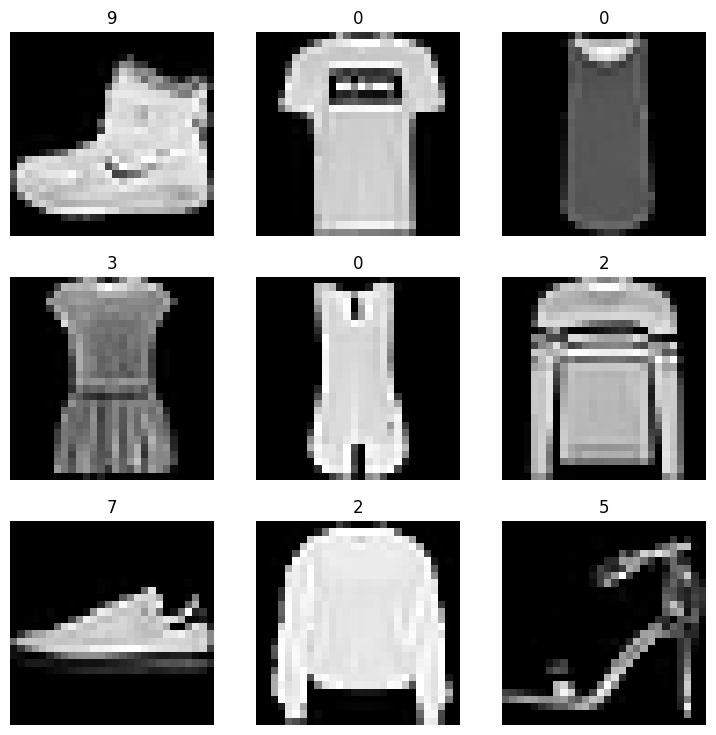

In [4]:
n_samples = 9
n_cols = 3
n_rows = n_samples // n_cols if n_samples % n_cols == 0 else n_samples // n_cols + 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for idx in range(n_samples):
    if idx >= n_samples:
        break

    image_np = train[idx][0].permute(1, 2, 0).cpu().detach().numpy()
    i = idx // n_cols
    j = idx % n_cols
    axs[i][j].imshow(image_np, cmap='gray')
    axs[i][j].set_title(train[idx][1])
    axs[i][j].axis('off')

plt.show()

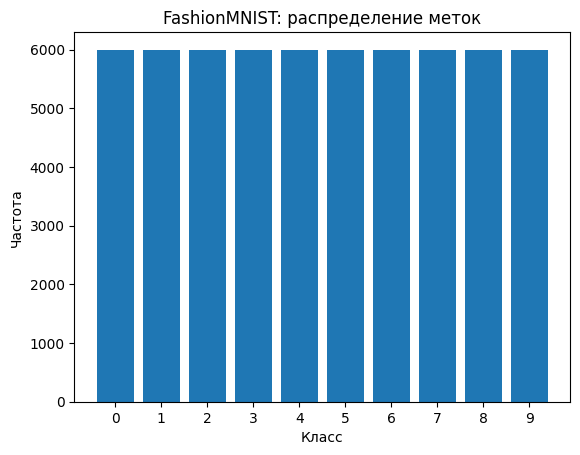

In [5]:
labels = train.targets

plt.hist(labels, bins=range(11), rwidth=0.8, align='left')
plt.xticks(range(10))
plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('FashionMNIST: распределение меток')
plt.show()

Заметим, что распределение классов строго равномерное

In [6]:
dataloader = DataLoader(train, batch_size=16, shuffle=True)

In [7]:
len(dataloader)

3750

## Vanilla GAN (JSD Loss)

Для сравнения сначала протестируем работу Vanilla GAN

In [52]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 28*28),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 200),
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

In [72]:
generator = Generator()
discriminator = Discriminator()

In [73]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

criterion = nn.BCELoss()

In [24]:
input = Variable(torch.FloatTensor(config.batch_size, 28*28))
noise = Variable(torch.FloatTensor(config.batch_size, config.noise_size))
fixed_noise = Variable(torch.FloatTensor(1, config.noise_size).normal_(0, 1))
label = Variable(torch.FloatTensor(config.batch_size))
real_label = 1
fake_label = 0

В процессе обучения после каждой эпохи генерируется изображение на фиксированном шуме для отслеживания изменения качества генерации.

Epoch:1 Iter: 500 errD_x: 0.20 errD_z: 0.07 errG: 2.89
Epoch:1 Iter: 1000 errD_x: 0.22 errD_z: 0.41 errG: 1.39
Epoch:1 Iter: 1500 errD_x: 0.29 errD_z: 0.24 errG: 2.00
Epoch:1 Iter: 2000 errD_x: 0.28 errD_z: 0.16 errG: 2.56
Epoch:1 Iter: 2500 errD_x: 0.56 errD_z: 0.08 errG: 3.01
Epoch:1 Iter: 3000 errD_x: 0.04 errD_z: 0.12 errG: 2.87
Epoch:1 Iter: 3500 errD_x: 0.08 errD_z: 0.02 errG: 4.35


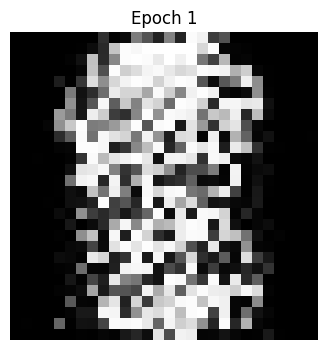

Epoch:2 Iter: 500 errD_x: 0.05 errD_z: 0.14 errG: 2.41
Epoch:2 Iter: 1000 errD_x: 0.23 errD_z: 0.23 errG: 1.76
Epoch:2 Iter: 1500 errD_x: 0.24 errD_z: 0.12 errG: 2.65
Epoch:2 Iter: 2000 errD_x: 0.07 errD_z: 0.05 errG: 3.54
Epoch:2 Iter: 2500 errD_x: 0.29 errD_z: 0.33 errG: 2.37
Epoch:2 Iter: 3000 errD_x: 0.36 errD_z: 0.10 errG: 2.70
Epoch:2 Iter: 3500 errD_x: 0.14 errD_z: 0.12 errG: 3.78


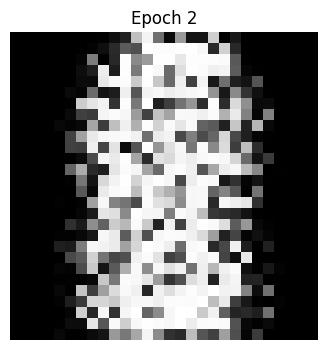

Epoch:3 Iter: 500 errD_x: 0.13 errD_z: 0.06 errG: 3.46
Epoch:3 Iter: 1000 errD_x: 0.25 errD_z: 0.05 errG: 3.72
Epoch:3 Iter: 1500 errD_x: 0.23 errD_z: 0.18 errG: 2.82
Epoch:3 Iter: 2000 errD_x: 0.20 errD_z: 0.17 errG: 2.92
Epoch:3 Iter: 2500 errD_x: 0.60 errD_z: 0.05 errG: 3.41
Epoch:3 Iter: 3000 errD_x: 0.09 errD_z: 0.06 errG: 3.68
Epoch:3 Iter: 3500 errD_x: 0.12 errD_z: 0.31 errG: 2.07


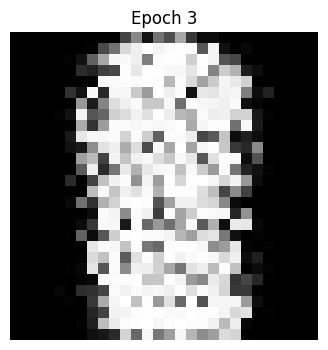

Epoch:4 Iter: 500 errD_x: 0.07 errD_z: 0.31 errG: 2.42
Epoch:4 Iter: 1000 errD_x: 0.57 errD_z: 0.16 errG: 2.12
Epoch:4 Iter: 1500 errD_x: 0.27 errD_z: 0.21 errG: 2.44
Epoch:4 Iter: 2000 errD_x: 0.04 errD_z: 0.30 errG: 2.49
Epoch:4 Iter: 2500 errD_x: 0.29 errD_z: 0.21 errG: 2.31
Epoch:4 Iter: 3000 errD_x: 0.10 errD_z: 0.39 errG: 1.86
Epoch:4 Iter: 3500 errD_x: 0.25 errD_z: 0.23 errG: 2.24


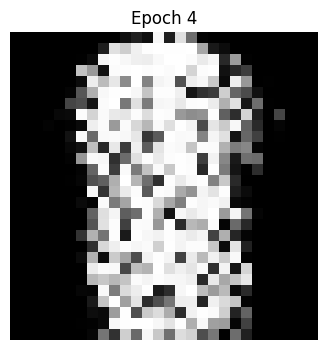

Epoch:5 Iter: 500 errD_x: 0.13 errD_z: 0.20 errG: 2.51
Epoch:5 Iter: 1000 errD_x: 0.68 errD_z: 0.09 errG: 2.67
Epoch:5 Iter: 1500 errD_x: 0.29 errD_z: 0.54 errG: 1.24
Epoch:5 Iter: 2000 errD_x: 0.24 errD_z: 0.20 errG: 2.32
Epoch:5 Iter: 2500 errD_x: 0.28 errD_z: 0.26 errG: 1.76
Epoch:5 Iter: 3000 errD_x: 0.61 errD_z: 0.16 errG: 2.17
Epoch:5 Iter: 3500 errD_x: 0.16 errD_z: 0.14 errG: 3.16


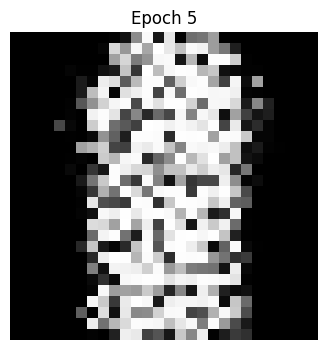

Epoch:6 Iter: 500 errD_x: 0.34 errD_z: 0.08 errG: 2.95
Epoch:6 Iter: 1000 errD_x: 0.19 errD_z: 0.35 errG: 2.19
Epoch:6 Iter: 1500 errD_x: 0.33 errD_z: 0.54 errG: 1.75
Epoch:6 Iter: 2000 errD_x: 0.13 errD_z: 0.18 errG: 2.48
Epoch:6 Iter: 2500 errD_x: 0.14 errD_z: 0.17 errG: 3.01
Epoch:6 Iter: 3000 errD_x: 0.24 errD_z: 0.11 errG: 2.85
Epoch:6 Iter: 3500 errD_x: 0.14 errD_z: 0.32 errG: 2.92


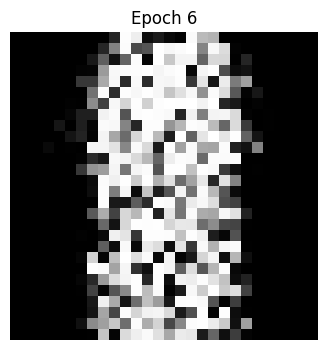

Epoch:7 Iter: 500 errD_x: 0.36 errD_z: 0.09 errG: 2.97
Epoch:7 Iter: 1000 errD_x: 0.17 errD_z: 0.18 errG: 2.20
Epoch:7 Iter: 1500 errD_x: 0.72 errD_z: 0.07 errG: 2.68
Epoch:7 Iter: 2000 errD_x: 0.32 errD_z: 0.32 errG: 2.68
Epoch:7 Iter: 2500 errD_x: 0.26 errD_z: 0.33 errG: 1.88
Epoch:7 Iter: 3000 errD_x: 0.38 errD_z: 0.52 errG: 1.06
Epoch:7 Iter: 3500 errD_x: 0.79 errD_z: 0.11 errG: 3.08


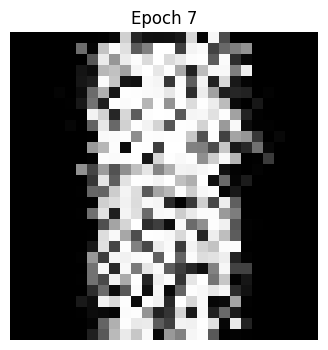

Epoch:8 Iter: 500 errD_x: 0.40 errD_z: 0.18 errG: 2.20
Epoch:8 Iter: 1000 errD_x: 0.24 errD_z: 0.07 errG: 2.72
Epoch:8 Iter: 1500 errD_x: 0.43 errD_z: 0.15 errG: 2.29
Epoch:8 Iter: 2000 errD_x: 0.53 errD_z: 0.15 errG: 1.90
Epoch:8 Iter: 2500 errD_x: 0.05 errD_z: 0.36 errG: 1.93
Epoch:8 Iter: 3000 errD_x: 0.37 errD_z: 0.37 errG: 1.70
Epoch:8 Iter: 3500 errD_x: 0.09 errD_z: 0.30 errG: 2.05


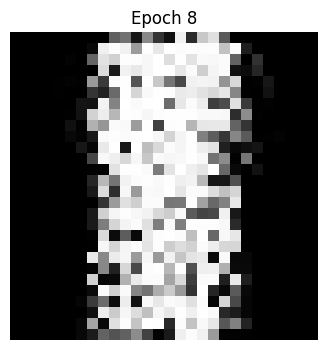

Epoch:9 Iter: 500 errD_x: 0.28 errD_z: 0.55 errG: 1.56
Epoch:9 Iter: 1000 errD_x: 0.23 errD_z: 0.24 errG: 1.91
Epoch:9 Iter: 1500 errD_x: 0.41 errD_z: 0.38 errG: 1.55
Epoch:9 Iter: 2000 errD_x: 0.59 errD_z: 0.13 errG: 2.65
Epoch:9 Iter: 2500 errD_x: 0.58 errD_z: 0.60 errG: 1.10
Epoch:9 Iter: 3000 errD_x: 0.26 errD_z: 0.47 errG: 1.27
Epoch:9 Iter: 3500 errD_x: 0.48 errD_z: 0.10 errG: 2.51


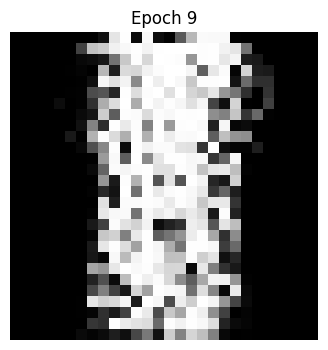

Epoch:10 Iter: 500 errD_x: 0.69 errD_z: 0.12 errG: 2.82
Epoch:10 Iter: 1000 errD_x: 0.76 errD_z: 0.18 errG: 1.90
Epoch:10 Iter: 1500 errD_x: 0.69 errD_z: 0.24 errG: 2.09
Epoch:10 Iter: 2000 errD_x: 0.20 errD_z: 0.13 errG: 2.18
Epoch:10 Iter: 2500 errD_x: 0.34 errD_z: 0.14 errG: 2.30
Epoch:10 Iter: 3000 errD_x: 0.42 errD_z: 0.38 errG: 1.51
Epoch:10 Iter: 3500 errD_x: 0.32 errD_z: 0.22 errG: 1.91


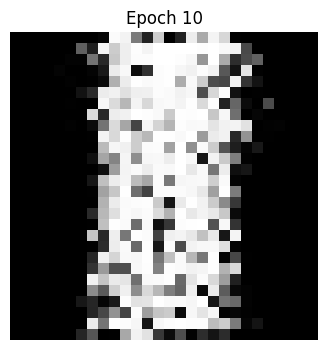

Epoch:11 Iter: 500 errD_x: 0.72 errD_z: 0.28 errG: 1.75
Epoch:11 Iter: 1000 errD_x: 0.27 errD_z: 0.15 errG: 2.22
Epoch:11 Iter: 1500 errD_x: 0.65 errD_z: 0.11 errG: 2.31
Epoch:11 Iter: 2000 errD_x: 0.15 errD_z: 0.50 errG: 1.38
Epoch:11 Iter: 2500 errD_x: 0.45 errD_z: 0.27 errG: 2.39
Epoch:11 Iter: 3000 errD_x: 0.20 errD_z: 0.52 errG: 1.31
Epoch:11 Iter: 3500 errD_x: 0.24 errD_z: 0.53 errG: 1.45


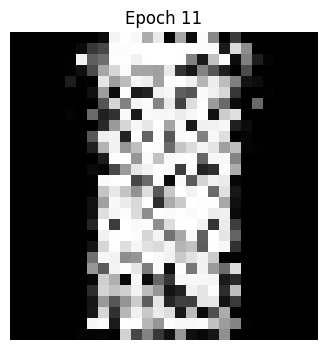

Epoch:12 Iter: 500 errD_x: 0.27 errD_z: 0.41 errG: 1.77
Epoch:12 Iter: 1000 errD_x: 0.21 errD_z: 0.14 errG: 2.02
Epoch:12 Iter: 1500 errD_x: 0.58 errD_z: 0.22 errG: 1.81
Epoch:12 Iter: 2000 errD_x: 0.82 errD_z: 0.19 errG: 2.49
Epoch:12 Iter: 2500 errD_x: 0.47 errD_z: 0.27 errG: 2.05
Epoch:12 Iter: 3000 errD_x: 0.44 errD_z: 0.15 errG: 2.31
Epoch:12 Iter: 3500 errD_x: 0.20 errD_z: 0.15 errG: 2.31


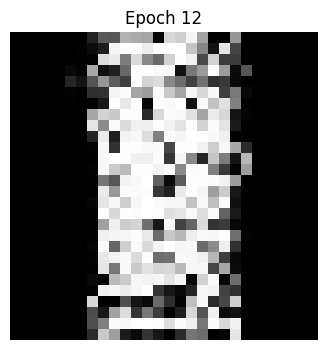

Epoch:13 Iter: 500 errD_x: 0.68 errD_z: 0.20 errG: 2.40
Epoch:13 Iter: 1000 errD_x: 0.41 errD_z: 0.21 errG: 1.93
Epoch:13 Iter: 1500 errD_x: 0.56 errD_z: 0.12 errG: 2.81
Epoch:13 Iter: 2000 errD_x: 0.25 errD_z: 0.27 errG: 2.13
Epoch:13 Iter: 2500 errD_x: 0.60 errD_z: 0.15 errG: 2.60
Epoch:13 Iter: 3000 errD_x: 0.71 errD_z: 0.12 errG: 2.03
Epoch:13 Iter: 3500 errD_x: 0.19 errD_z: 0.64 errG: 1.93


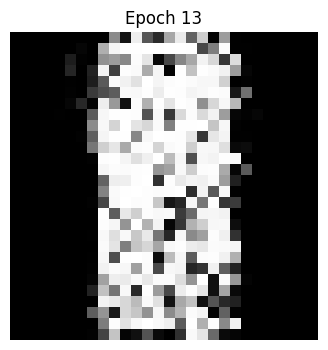

Epoch:14 Iter: 500 errD_x: 0.60 errD_z: 0.41 errG: 1.49
Epoch:14 Iter: 1000 errD_x: 0.56 errD_z: 0.47 errG: 1.90
Epoch:14 Iter: 1500 errD_x: 0.69 errD_z: 0.40 errG: 1.44
Epoch:14 Iter: 2000 errD_x: 0.43 errD_z: 0.21 errG: 1.83
Epoch:14 Iter: 2500 errD_x: 0.65 errD_z: 0.13 errG: 2.73
Epoch:14 Iter: 3000 errD_x: 0.21 errD_z: 0.30 errG: 1.94
Epoch:14 Iter: 3500 errD_x: 0.21 errD_z: 0.25 errG: 2.32


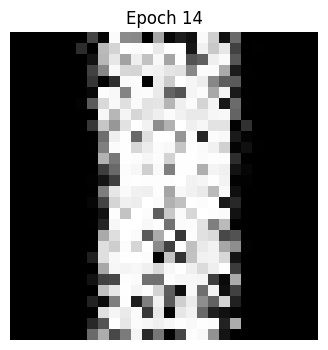

Epoch:15 Iter: 500 errD_x: 0.31 errD_z: 0.30 errG: 1.94
Epoch:15 Iter: 1000 errD_x: 0.22 errD_z: 0.63 errG: 1.22
Epoch:15 Iter: 1500 errD_x: 0.20 errD_z: 0.56 errG: 1.29
Epoch:15 Iter: 2000 errD_x: 0.40 errD_z: 0.45 errG: 1.27
Epoch:15 Iter: 2500 errD_x: 0.65 errD_z: 0.05 errG: 3.05
Epoch:15 Iter: 3000 errD_x: 0.20 errD_z: 0.18 errG: 2.19
Epoch:15 Iter: 3500 errD_x: 0.32 errD_z: 0.25 errG: 1.76


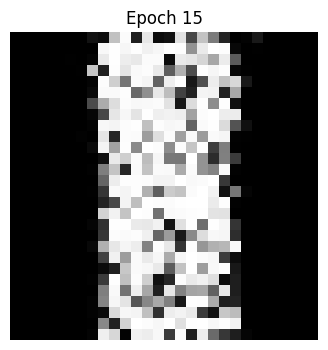

Epoch:16 Iter: 500 errD_x: 0.09 errD_z: 0.49 errG: 1.96
Epoch:16 Iter: 1000 errD_x: 0.47 errD_z: 0.27 errG: 2.18
Epoch:16 Iter: 1500 errD_x: 0.34 errD_z: 0.39 errG: 1.43
Epoch:16 Iter: 2000 errD_x: 0.54 errD_z: 0.16 errG: 2.28
Epoch:16 Iter: 2500 errD_x: 0.54 errD_z: 0.21 errG: 1.60
Epoch:16 Iter: 3000 errD_x: 0.40 errD_z: 0.42 errG: 1.85
Epoch:16 Iter: 3500 errD_x: 0.66 errD_z: 0.27 errG: 2.25


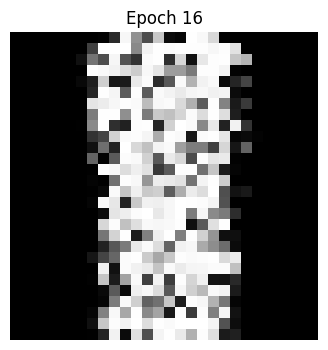

Epoch:17 Iter: 500 errD_x: 0.52 errD_z: 0.51 errG: 1.03
Epoch:17 Iter: 1000 errD_x: 0.86 errD_z: 0.42 errG: 2.09
Epoch:17 Iter: 1500 errD_x: 1.08 errD_z: 0.16 errG: 2.17
Epoch:17 Iter: 2000 errD_x: 0.39 errD_z: 0.42 errG: 2.51
Epoch:17 Iter: 2500 errD_x: 0.49 errD_z: 0.23 errG: 2.08
Epoch:17 Iter: 3000 errD_x: 0.75 errD_z: 0.15 errG: 2.26
Epoch:17 Iter: 3500 errD_x: 0.24 errD_z: 0.43 errG: 1.14


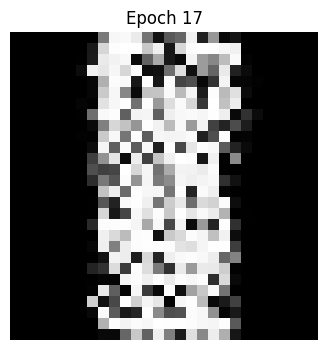

Epoch:18 Iter: 500 errD_x: 1.05 errD_z: 0.42 errG: 1.55
Epoch:18 Iter: 1000 errD_x: 0.27 errD_z: 0.39 errG: 1.26
Epoch:18 Iter: 1500 errD_x: 0.57 errD_z: 0.35 errG: 1.77
Epoch:18 Iter: 2000 errD_x: 0.62 errD_z: 0.14 errG: 2.24
Epoch:18 Iter: 2500 errD_x: 0.19 errD_z: 0.23 errG: 2.08
Epoch:18 Iter: 3000 errD_x: 0.25 errD_z: 0.19 errG: 2.08
Epoch:18 Iter: 3500 errD_x: 0.38 errD_z: 0.24 errG: 1.70


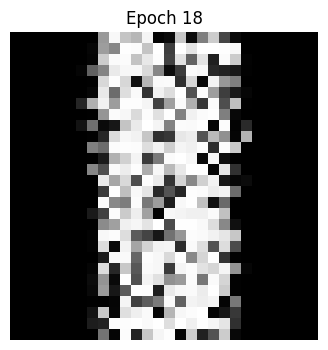

Epoch:19 Iter: 500 errD_x: 0.53 errD_z: 0.30 errG: 1.90
Epoch:19 Iter: 1000 errD_x: 0.23 errD_z: 0.31 errG: 1.94
Epoch:19 Iter: 1500 errD_x: 0.83 errD_z: 0.95 errG: 1.50
Epoch:19 Iter: 2000 errD_x: 0.40 errD_z: 0.35 errG: 1.42
Epoch:19 Iter: 2500 errD_x: 0.93 errD_z: 0.14 errG: 2.48
Epoch:19 Iter: 3000 errD_x: 0.81 errD_z: 0.55 errG: 1.61
Epoch:19 Iter: 3500 errD_x: 0.28 errD_z: 0.34 errG: 1.83


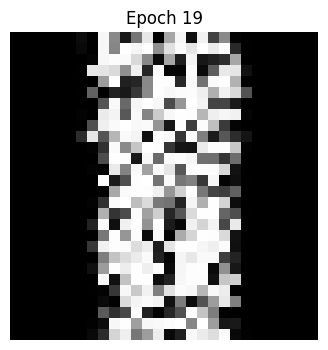

Epoch:20 Iter: 500 errD_x: 0.09 errD_z: 0.30 errG: 1.65
Epoch:20 Iter: 1000 errD_x: 0.48 errD_z: 0.35 errG: 1.77
Epoch:20 Iter: 1500 errD_x: 0.52 errD_z: 0.22 errG: 2.37
Epoch:20 Iter: 2000 errD_x: 0.62 errD_z: 0.23 errG: 2.10
Epoch:20 Iter: 2500 errD_x: 0.46 errD_z: 0.27 errG: 1.94
Epoch:20 Iter: 3000 errD_x: 0.36 errD_z: 0.50 errG: 1.40
Epoch:20 Iter: 3500 errD_x: 0.67 errD_z: 0.20 errG: 1.90


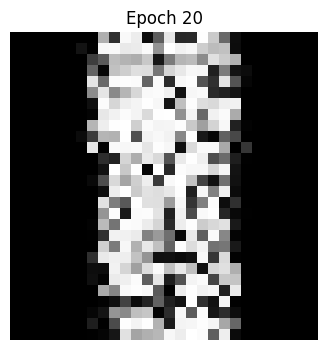

Epoch:21 Iter: 500 errD_x: 0.31 errD_z: 0.30 errG: 2.09
Epoch:21 Iter: 1000 errD_x: 0.23 errD_z: 0.51 errG: 1.39
Epoch:21 Iter: 1500 errD_x: 0.66 errD_z: 0.58 errG: 1.45
Epoch:21 Iter: 2000 errD_x: 0.68 errD_z: 0.39 errG: 1.78
Epoch:21 Iter: 2500 errD_x: 0.63 errD_z: 0.26 errG: 1.30
Epoch:21 Iter: 3000 errD_x: 0.61 errD_z: 0.30 errG: 1.81
Epoch:21 Iter: 3500 errD_x: 0.16 errD_z: 0.42 errG: 1.96


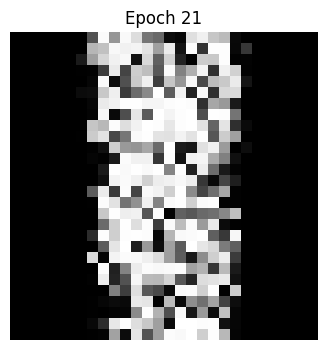

Epoch:22 Iter: 500 errD_x: 0.71 errD_z: 0.18 errG: 2.18
Epoch:22 Iter: 1000 errD_x: 0.46 errD_z: 0.11 errG: 2.39
Epoch:22 Iter: 1500 errD_x: 0.38 errD_z: 0.28 errG: 1.71
Epoch:22 Iter: 2000 errD_x: 0.53 errD_z: 0.37 errG: 1.92
Epoch:22 Iter: 2500 errD_x: 0.30 errD_z: 0.50 errG: 1.52
Epoch:22 Iter: 3000 errD_x: 0.51 errD_z: 0.21 errG: 1.98
Epoch:22 Iter: 3500 errD_x: 0.25 errD_z: 0.31 errG: 2.46


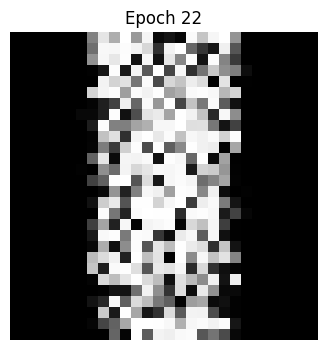

Epoch:23 Iter: 500 errD_x: 0.81 errD_z: 0.23 errG: 1.89
Epoch:23 Iter: 1000 errD_x: 0.56 errD_z: 0.26 errG: 2.20
Epoch:23 Iter: 1500 errD_x: 0.53 errD_z: 0.34 errG: 1.65
Epoch:23 Iter: 2000 errD_x: 0.23 errD_z: 0.41 errG: 2.15
Epoch:23 Iter: 2500 errD_x: 0.21 errD_z: 0.16 errG: 2.52
Epoch:23 Iter: 3000 errD_x: 0.71 errD_z: 0.38 errG: 1.79
Epoch:23 Iter: 3500 errD_x: 0.28 errD_z: 0.24 errG: 2.50


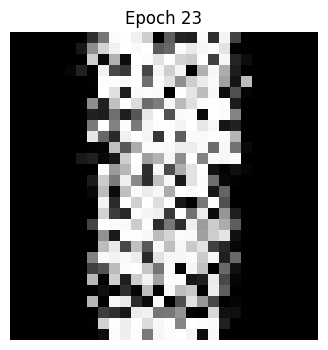

Epoch:24 Iter: 500 errD_x: 0.52 errD_z: 0.21 errG: 2.30
Epoch:24 Iter: 1000 errD_x: 0.74 errD_z: 0.40 errG: 2.06
Epoch:24 Iter: 1500 errD_x: 0.99 errD_z: 0.39 errG: 1.48
Epoch:24 Iter: 2000 errD_x: 0.87 errD_z: 0.23 errG: 2.48
Epoch:24 Iter: 2500 errD_x: 0.51 errD_z: 0.23 errG: 2.77
Epoch:24 Iter: 3000 errD_x: 0.47 errD_z: 0.28 errG: 1.80
Epoch:24 Iter: 3500 errD_x: 0.53 errD_z: 0.13 errG: 2.55


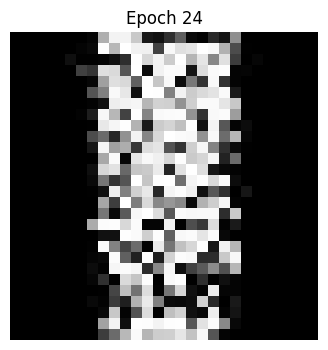

Epoch:25 Iter: 500 errD_x: 0.30 errD_z: 0.26 errG: 1.90
Epoch:25 Iter: 1000 errD_x: 0.65 errD_z: 0.24 errG: 2.19
Epoch:25 Iter: 1500 errD_x: 0.35 errD_z: 0.33 errG: 1.95
Epoch:25 Iter: 2000 errD_x: 1.06 errD_z: 0.23 errG: 2.60
Epoch:25 Iter: 2500 errD_x: 0.13 errD_z: 0.44 errG: 1.31
Epoch:25 Iter: 3000 errD_x: 1.04 errD_z: 0.15 errG: 2.53
Epoch:25 Iter: 3500 errD_x: 0.25 errD_z: 0.31 errG: 1.77


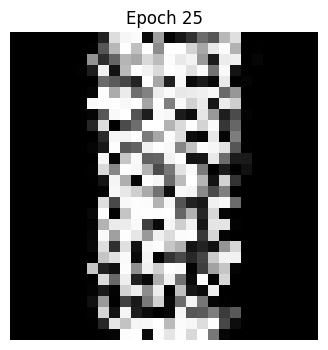

Epoch:26 Iter: 500 errD_x: 0.48 errD_z: 0.17 errG: 1.72
Epoch:26 Iter: 1000 errD_x: 0.55 errD_z: 0.25 errG: 1.76
Epoch:26 Iter: 1500 errD_x: 0.19 errD_z: 0.66 errG: 1.46
Epoch:26 Iter: 2000 errD_x: 0.70 errD_z: 0.44 errG: 1.80
Epoch:26 Iter: 2500 errD_x: 0.52 errD_z: 0.19 errG: 2.34
Epoch:26 Iter: 3000 errD_x: 0.67 errD_z: 0.30 errG: 1.94
Epoch:26 Iter: 3500 errD_x: 0.28 errD_z: 0.43 errG: 1.93


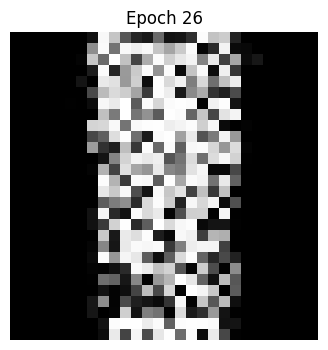

Epoch:27 Iter: 500 errD_x: 0.29 errD_z: 0.54 errG: 2.00
Epoch:27 Iter: 1000 errD_x: 0.83 errD_z: 0.56 errG: 1.78
Epoch:27 Iter: 1500 errD_x: 0.56 errD_z: 0.23 errG: 1.75
Epoch:27 Iter: 2000 errD_x: 0.06 errD_z: 0.93 errG: 0.98
Epoch:27 Iter: 2500 errD_x: 0.79 errD_z: 0.33 errG: 1.50
Epoch:27 Iter: 3000 errD_x: 0.13 errD_z: 0.47 errG: 1.82
Epoch:27 Iter: 3500 errD_x: 0.15 errD_z: 0.22 errG: 2.37


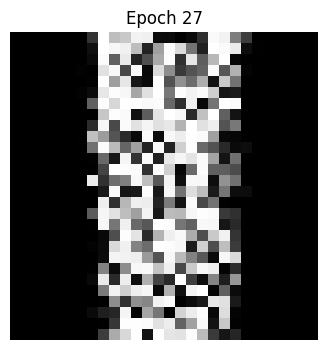

Epoch:28 Iter: 500 errD_x: 0.32 errD_z: 0.36 errG: 1.79
Epoch:28 Iter: 1000 errD_x: 0.43 errD_z: 0.25 errG: 2.01
Epoch:28 Iter: 1500 errD_x: 0.53 errD_z: 0.26 errG: 1.72
Epoch:28 Iter: 2000 errD_x: 0.41 errD_z: 0.36 errG: 2.04
Epoch:28 Iter: 2500 errD_x: 0.20 errD_z: 0.13 errG: 2.60
Epoch:28 Iter: 3000 errD_x: 0.86 errD_z: 0.39 errG: 1.64
Epoch:28 Iter: 3500 errD_x: 0.38 errD_z: 0.40 errG: 1.31


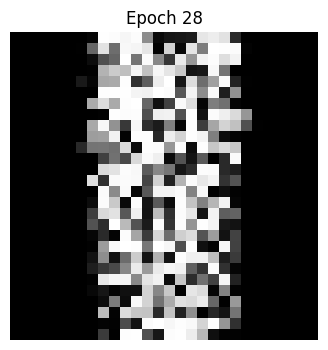

Epoch:29 Iter: 500 errD_x: 0.25 errD_z: 0.28 errG: 1.89
Epoch:29 Iter: 1000 errD_x: 0.42 errD_z: 0.42 errG: 1.88
Epoch:29 Iter: 1500 errD_x: 0.58 errD_z: 0.56 errG: 1.47
Epoch:29 Iter: 2000 errD_x: 0.91 errD_z: 1.00 errG: 1.44
Epoch:29 Iter: 2500 errD_x: 0.26 errD_z: 0.43 errG: 1.98
Epoch:29 Iter: 3000 errD_x: 0.50 errD_z: 0.22 errG: 2.31
Epoch:29 Iter: 3500 errD_x: 0.77 errD_z: 0.31 errG: 1.74


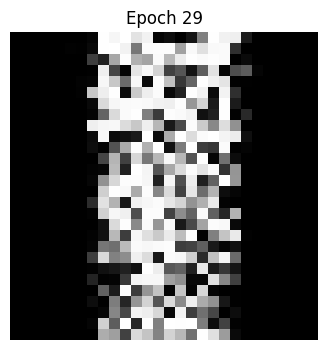

Epoch:30 Iter: 500 errD_x: 0.50 errD_z: 0.43 errG: 1.38
Epoch:30 Iter: 1000 errD_x: 0.36 errD_z: 0.38 errG: 1.55
Epoch:30 Iter: 1500 errD_x: 0.36 errD_z: 0.22 errG: 1.90
Epoch:30 Iter: 2000 errD_x: 0.58 errD_z: 0.38 errG: 1.33
Epoch:30 Iter: 2500 errD_x: 0.75 errD_z: 0.38 errG: 1.77
Epoch:30 Iter: 3000 errD_x: 0.38 errD_z: 0.24 errG: 2.23
Epoch:30 Iter: 3500 errD_x: 0.52 errD_z: 0.15 errG: 2.62


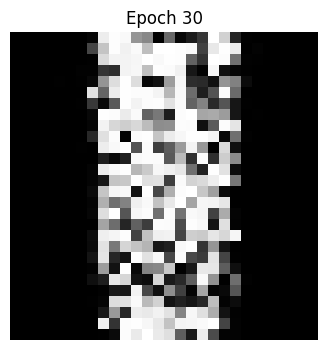

In [75]:
ERRD_x = np.zeros(config.num_epochs)
ERRD_z = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)

for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):
        #######
        # Discriminator stage: maximize log(D(x)) + log(1 - D(G(z)))
        #######
        discriminator.zero_grad()

        # real
        label.data.fill_(real_label)
        input_data = images.view(images.shape[0], -1)
        output = discriminator(input_data).squeeze()
        errD_x = criterion(output, label)
        ERRD_x[epoch] += errD_x.item()
        errD_x.backward()

        # fake
        noise.data.normal_(0, 1)
        fake = generator(noise)
        label.data.fill_(fake_label)
        output = discriminator(fake.detach()).squeeze()
        errD_z = criterion(output, label)
        ERRD_z[epoch] += errD_z.item()
        errD_z.backward()

        optim_D.step()

        #######
        # Generator stage: maximize log(D(G(x))
        #######
        generator.zero_grad()
        label.data.fill_(real_label)
        output = discriminator(fake).squeeze()
        errG = criterion(output, label)
        ERRG[epoch] += errG.item()
        errG.backward()

        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD_x: {:.2f} errD_z: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                                            iteration+1,
                                                                                            errD_x.item(),
                                                                                            errD_z.item(),
                                                                                            errG.item()))

    test_epoch_generation = generator(fixed_noise)
    plt.figure(figsize=(4, 4))
    plt.imshow(test_epoch_generation[0].detach().cpu().numpy().reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    plt.title(f'Epoch {epoch+1}')
    plt.show()

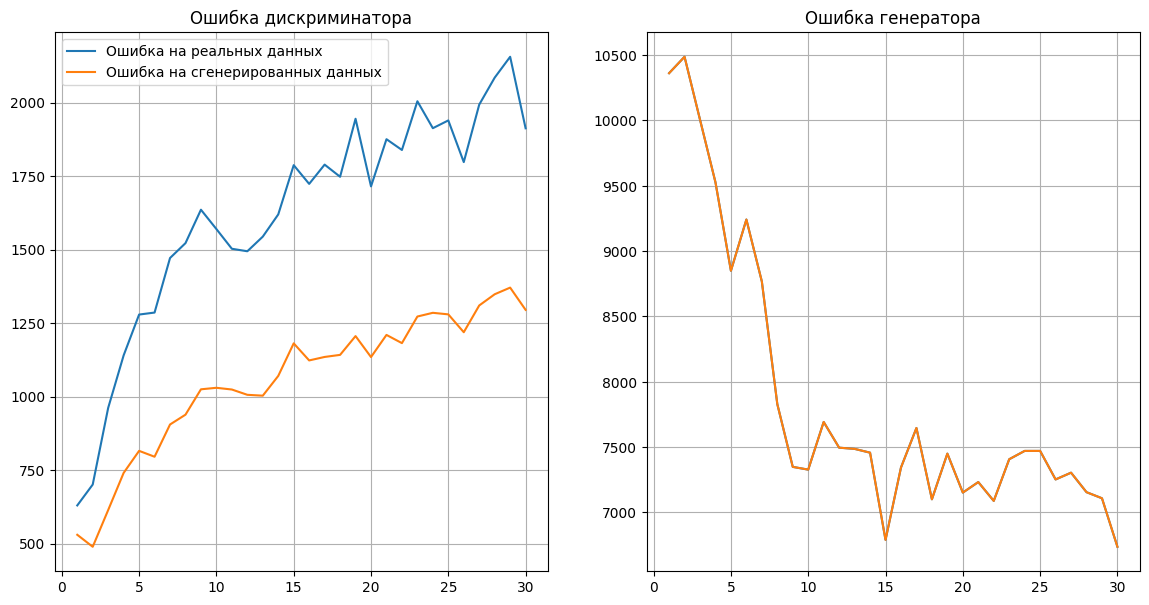

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].plot(np.arange(1, config.num_epochs + 1), ERRD_x, label='Ошибка на реальных данных')
axs[0].plot(np.arange(1, config.num_epochs + 1), ERRD_z, label='Ошибка на сгенерированных данных')
axs[0].set_title('Ошибка дискриминатора')
axs[0].legend()
axs[0].grid()

axs[1].plot(np.arange(1, config.num_epochs + 1), ERRG)
axs[1].set_title('Ошибка генератора')
axs[1].grid()

plt.show()

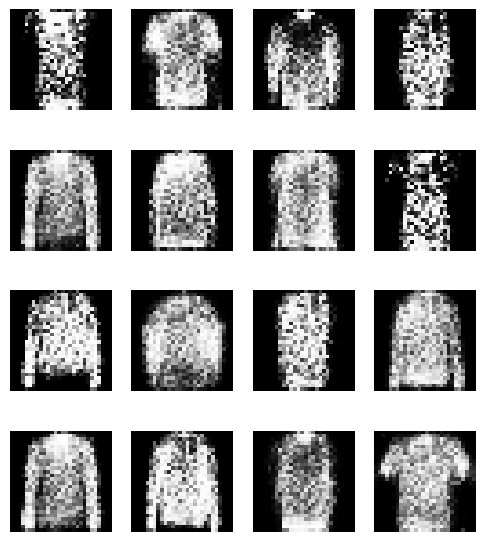

In [78]:
noise.data.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

За 30 эпох обучения сгенерированные изображения похожи на одежду. Заметен mode collapse: сгенерированные изображения - преимущественно лонгсливы, футболки и платья (при этом совсем нет брюк и обуви)

## WGAN (WD Loss)

### Weight clipping

In [79]:
generator = Generator()
discriminator = Discriminator()

In [80]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

Epoch:1 Iter: 500 errD: -0.03 errG: -0.48
Epoch:1 Iter: 1000 errD: -0.03 errG: -0.50
Epoch:1 Iter: 1500 errD: -0.01 errG: -0.49
Epoch:1 Iter: 2000 errD: -0.00 errG: -0.49
Epoch:1 Iter: 2500 errD: -0.01 errG: -0.49
Epoch:1 Iter: 3000 errD: -0.00 errG: -0.49
Epoch:1 Iter: 3500 errD: -0.00 errG: -0.50


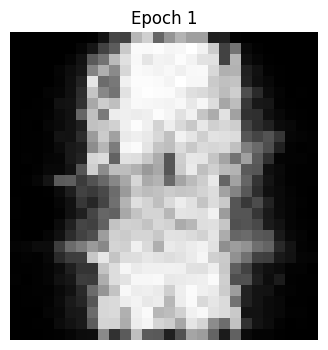

Epoch:2 Iter: 500 errD: -0.01 errG: -0.51
Epoch:2 Iter: 1000 errD: -0.01 errG: -0.50
Epoch:2 Iter: 1500 errD: -0.01 errG: -0.49
Epoch:2 Iter: 2000 errD: -0.01 errG: -0.50
Epoch:2 Iter: 2500 errD: -0.01 errG: -0.50
Epoch:2 Iter: 3000 errD: -0.01 errG: -0.50
Epoch:2 Iter: 3500 errD: -0.01 errG: -0.50


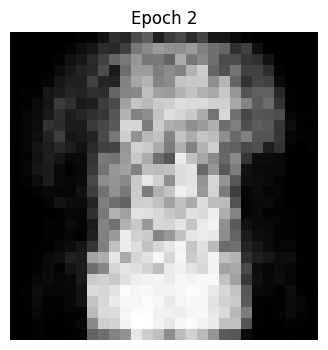

Epoch:3 Iter: 500 errD: -0.01 errG: -0.50
Epoch:3 Iter: 1000 errD: -0.01 errG: -0.49
Epoch:3 Iter: 1500 errD: -0.01 errG: -0.49
Epoch:3 Iter: 2000 errD: -0.01 errG: -0.49
Epoch:3 Iter: 2500 errD: -0.00 errG: -0.50
Epoch:3 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:3 Iter: 3500 errD: -0.01 errG: -0.50


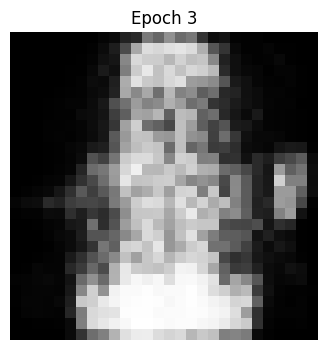

Epoch:4 Iter: 500 errD: -0.00 errG: -0.49
Epoch:4 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:4 Iter: 1500 errD: -0.00 errG: -0.51
Epoch:4 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:4 Iter: 2500 errD: -0.01 errG: -0.50
Epoch:4 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:4 Iter: 3500 errD: -0.00 errG: -0.49


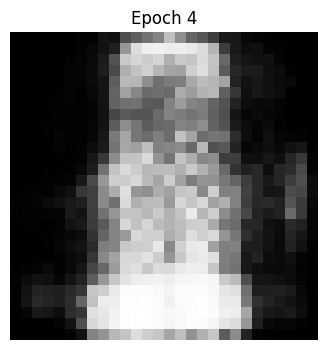

Epoch:5 Iter: 500 errD: -0.00 errG: -0.50
Epoch:5 Iter: 1000 errD: -0.00 errG: -0.51
Epoch:5 Iter: 1500 errD: -0.00 errG: -0.51
Epoch:5 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:5 Iter: 2500 errD: -0.00 errG: -0.49
Epoch:5 Iter: 3000 errD: -0.00 errG: -0.51
Epoch:5 Iter: 3500 errD: 0.00 errG: -0.50


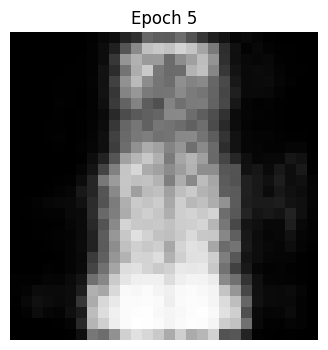

Epoch:6 Iter: 500 errD: -0.01 errG: -0.48
Epoch:6 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:6 Iter: 1500 errD: 0.01 errG: -0.53
Epoch:6 Iter: 2000 errD: -0.00 errG: -0.51
Epoch:6 Iter: 2500 errD: -0.01 errG: -0.47
Epoch:6 Iter: 3000 errD: 0.01 errG: -0.55
Epoch:6 Iter: 3500 errD: 0.00 errG: -0.49


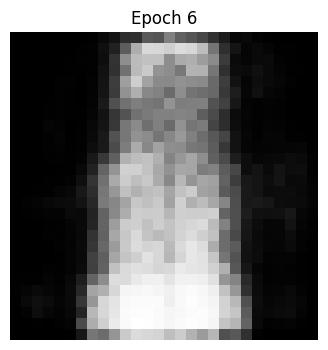

Epoch:7 Iter: 500 errD: -0.01 errG: -0.53
Epoch:7 Iter: 1000 errD: -0.00 errG: -0.49
Epoch:7 Iter: 1500 errD: 0.01 errG: -0.50
Epoch:7 Iter: 2000 errD: 0.02 errG: -0.57
Epoch:7 Iter: 2500 errD: -0.01 errG: -0.44
Epoch:7 Iter: 3000 errD: 0.01 errG: -0.49
Epoch:7 Iter: 3500 errD: -0.02 errG: -0.52


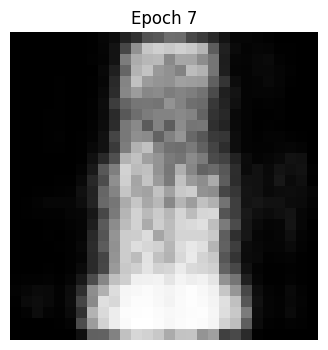

Epoch:8 Iter: 500 errD: 0.02 errG: -0.45
Epoch:8 Iter: 1000 errD: -0.00 errG: -0.49
Epoch:8 Iter: 1500 errD: 0.00 errG: -0.50
Epoch:8 Iter: 2000 errD: -0.01 errG: -0.54
Epoch:8 Iter: 2500 errD: -0.00 errG: -0.54
Epoch:8 Iter: 3000 errD: 0.02 errG: -0.60
Epoch:8 Iter: 3500 errD: 0.01 errG: -0.55


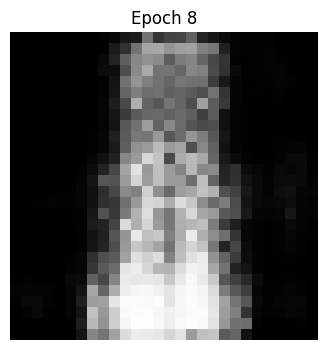

Epoch:9 Iter: 500 errD: -0.01 errG: -0.57
Epoch:9 Iter: 1000 errD: -0.02 errG: -0.58
Epoch:9 Iter: 1500 errD: 0.00 errG: -0.51
Epoch:9 Iter: 2000 errD: -0.01 errG: -0.44
Epoch:9 Iter: 2500 errD: 0.02 errG: -0.46
Epoch:9 Iter: 3000 errD: 0.01 errG: -0.46
Epoch:9 Iter: 3500 errD: 0.01 errG: -0.49


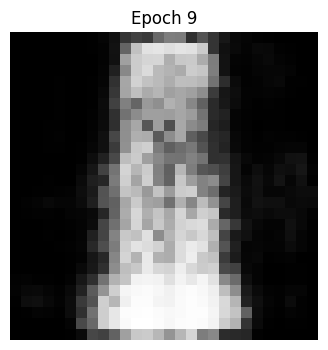

Epoch:10 Iter: 500 errD: -0.03 errG: -0.45
Epoch:10 Iter: 1000 errD: -0.03 errG: -0.42
Epoch:10 Iter: 1500 errD: 0.01 errG: -0.44
Epoch:10 Iter: 2000 errD: 0.01 errG: -0.46
Epoch:10 Iter: 2500 errD: 0.00 errG: -0.47
Epoch:10 Iter: 3000 errD: -0.00 errG: -0.49
Epoch:10 Iter: 3500 errD: 0.03 errG: -0.48


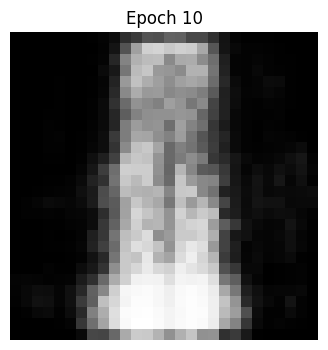

Epoch:11 Iter: 500 errD: 0.01 errG: -0.58
Epoch:11 Iter: 1000 errD: 0.00 errG: -0.57
Epoch:11 Iter: 1500 errD: 0.01 errG: -0.54
Epoch:11 Iter: 2000 errD: 0.02 errG: -0.54
Epoch:11 Iter: 2500 errD: 0.00 errG: -0.57
Epoch:11 Iter: 3000 errD: 0.01 errG: -0.55
Epoch:11 Iter: 3500 errD: -0.01 errG: -0.54


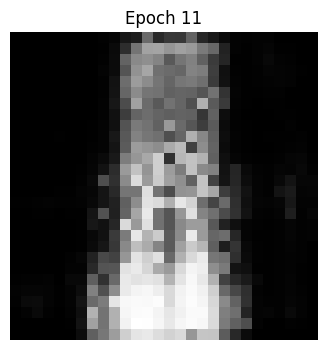

Epoch:12 Iter: 500 errD: 0.00 errG: -0.50
Epoch:12 Iter: 1000 errD: 0.00 errG: -0.49
Epoch:12 Iter: 1500 errD: -0.00 errG: -0.45
Epoch:12 Iter: 2000 errD: -0.01 errG: -0.46
Epoch:12 Iter: 2500 errD: 0.01 errG: -0.49
Epoch:12 Iter: 3000 errD: 0.00 errG: -0.49
Epoch:12 Iter: 3500 errD: 0.01 errG: -0.45


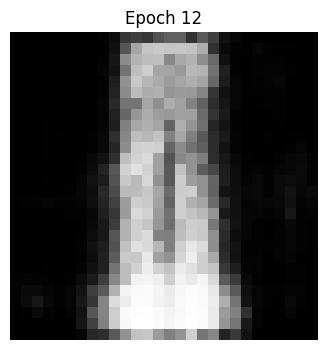

Epoch:13 Iter: 500 errD: 0.01 errG: -0.57
Epoch:13 Iter: 1000 errD: 0.02 errG: -0.55
Epoch:13 Iter: 1500 errD: 0.00 errG: -0.51
Epoch:13 Iter: 2000 errD: -0.01 errG: -0.49
Epoch:13 Iter: 2500 errD: -0.01 errG: -0.44
Epoch:13 Iter: 3000 errD: -0.00 errG: -0.44
Epoch:13 Iter: 3500 errD: 0.00 errG: -0.48


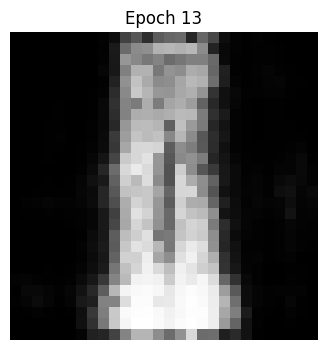

Epoch:14 Iter: 500 errD: -0.00 errG: -0.50
Epoch:14 Iter: 1000 errD: -0.01 errG: -0.47
Epoch:14 Iter: 1500 errD: 0.01 errG: -0.43
Epoch:14 Iter: 2000 errD: -0.01 errG: -0.40
Epoch:14 Iter: 2500 errD: -0.03 errG: -0.40
Epoch:14 Iter: 3000 errD: -0.01 errG: -0.41
Epoch:14 Iter: 3500 errD: 0.04 errG: -0.46


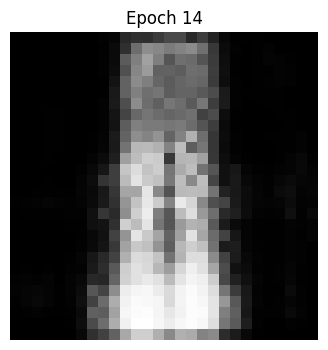

Epoch:15 Iter: 500 errD: -0.03 errG: -0.57
Epoch:15 Iter: 1000 errD: 0.03 errG: -0.62
Epoch:15 Iter: 1500 errD: -0.05 errG: -0.58
Epoch:15 Iter: 2000 errD: -0.05 errG: -0.60
Epoch:15 Iter: 2500 errD: -0.02 errG: -0.58
Epoch:15 Iter: 3000 errD: -0.02 errG: -0.59
Epoch:15 Iter: 3500 errD: -0.00 errG: -0.61


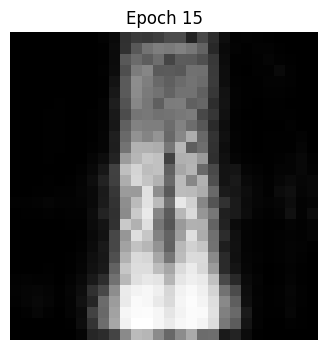

Epoch:16 Iter: 500 errD: -0.02 errG: -0.37
Epoch:16 Iter: 1000 errD: -0.02 errG: -0.41
Epoch:16 Iter: 1500 errD: 0.01 errG: -0.45
Epoch:16 Iter: 2000 errD: 0.01 errG: -0.44
Epoch:16 Iter: 2500 errD: 0.00 errG: -0.43
Epoch:16 Iter: 3000 errD: 0.01 errG: -0.45
Epoch:16 Iter: 3500 errD: 0.00 errG: -0.49


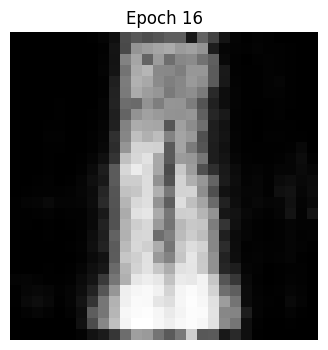

Epoch:17 Iter: 500 errD: 0.01 errG: -0.45
Epoch:17 Iter: 1000 errD: -0.01 errG: -0.44
Epoch:17 Iter: 1500 errD: -0.02 errG: -0.43
Epoch:17 Iter: 2000 errD: 0.01 errG: -0.47
Epoch:17 Iter: 2500 errD: 0.00 errG: -0.49
Epoch:17 Iter: 3000 errD: -0.00 errG: -0.49
Epoch:17 Iter: 3500 errD: 0.00 errG: -0.49


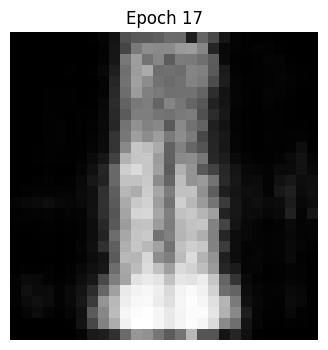

Epoch:18 Iter: 500 errD: 0.00 errG: -0.53
Epoch:18 Iter: 1000 errD: 0.01 errG: -0.63
Epoch:18 Iter: 1500 errD: 0.00 errG: -0.61
Epoch:18 Iter: 2000 errD: 0.00 errG: -0.62
Epoch:18 Iter: 2500 errD: -0.00 errG: -0.52
Epoch:18 Iter: 3000 errD: 0.01 errG: -0.49
Epoch:18 Iter: 3500 errD: -0.03 errG: -0.36


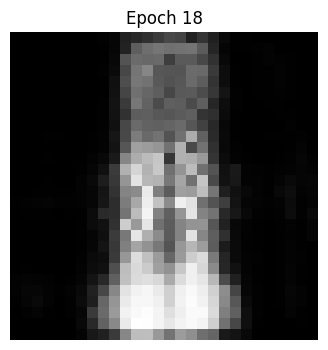

Epoch:19 Iter: 500 errD: 0.00 errG: -0.49
Epoch:19 Iter: 1000 errD: 0.02 errG: -0.41
Epoch:19 Iter: 1500 errD: -0.00 errG: -0.51
Epoch:19 Iter: 2000 errD: -0.00 errG: -0.51
Epoch:19 Iter: 2500 errD: 0.01 errG: -0.40
Epoch:19 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:19 Iter: 3500 errD: -0.00 errG: -0.58


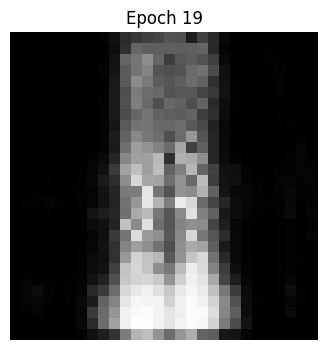

Epoch:20 Iter: 500 errD: -0.02 errG: -0.42
Epoch:20 Iter: 1000 errD: -0.01 errG: -0.41
Epoch:20 Iter: 1500 errD: 0.00 errG: -0.43
Epoch:20 Iter: 2000 errD: -0.02 errG: -0.40
Epoch:20 Iter: 2500 errD: -0.02 errG: -0.45
Epoch:20 Iter: 3000 errD: 0.01 errG: -0.47
Epoch:20 Iter: 3500 errD: 0.00 errG: -0.42


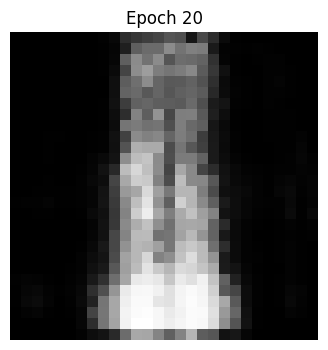

Epoch:21 Iter: 500 errD: 0.02 errG: -0.62
Epoch:21 Iter: 1000 errD: -0.00 errG: -0.53
Epoch:21 Iter: 1500 errD: -0.00 errG: -0.51
Epoch:21 Iter: 2000 errD: 0.00 errG: -0.49
Epoch:21 Iter: 2500 errD: -0.00 errG: -0.46
Epoch:21 Iter: 3000 errD: 0.02 errG: -0.46
Epoch:21 Iter: 3500 errD: 0.02 errG: -0.43


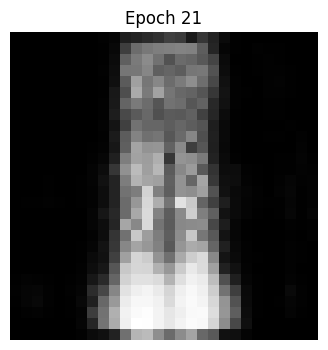

Epoch:22 Iter: 500 errD: -0.00 errG: -0.53
Epoch:22 Iter: 1000 errD: -0.01 errG: -0.52
Epoch:22 Iter: 1500 errD: -0.00 errG: -0.50
Epoch:22 Iter: 2000 errD: 0.01 errG: -0.48
Epoch:22 Iter: 2500 errD: 0.01 errG: -0.42
Epoch:22 Iter: 3000 errD: 0.04 errG: -0.41
Epoch:22 Iter: 3500 errD: -0.01 errG: -0.39


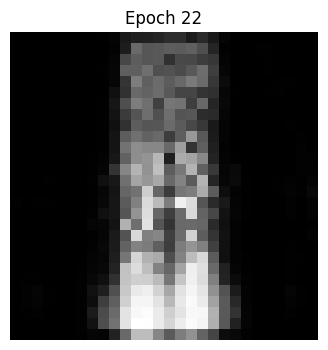

Epoch:23 Iter: 500 errD: 0.00 errG: -0.49
Epoch:23 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:23 Iter: 1500 errD: 0.03 errG: -0.46
Epoch:23 Iter: 2000 errD: -0.00 errG: -0.40
Epoch:23 Iter: 2500 errD: -0.00 errG: -0.42
Epoch:23 Iter: 3000 errD: -0.00 errG: -0.42
Epoch:23 Iter: 3500 errD: -0.00 errG: -0.48


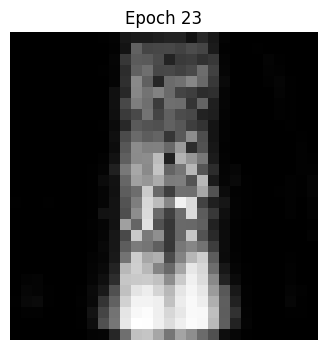

Epoch:24 Iter: 500 errD: 0.01 errG: -0.46
Epoch:24 Iter: 1000 errD: -0.00 errG: -0.43
Epoch:24 Iter: 1500 errD: 0.02 errG: -0.43
Epoch:24 Iter: 2000 errD: -0.03 errG: -0.41
Epoch:24 Iter: 2500 errD: -0.01 errG: -0.42
Epoch:24 Iter: 3000 errD: -0.00 errG: -0.49
Epoch:24 Iter: 3500 errD: 0.00 errG: -0.51


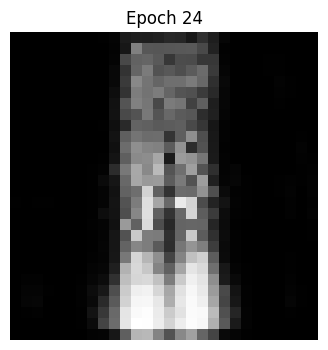

Epoch:25 Iter: 500 errD: -0.01 errG: -0.37
Epoch:25 Iter: 1000 errD: -0.00 errG: -0.48
Epoch:25 Iter: 1500 errD: 0.00 errG: -0.59
Epoch:25 Iter: 2000 errD: 0.02 errG: -0.65
Epoch:25 Iter: 2500 errD: -0.00 errG: -0.51
Epoch:25 Iter: 3000 errD: 0.00 errG: -0.50
Epoch:25 Iter: 3500 errD: 0.01 errG: -0.40


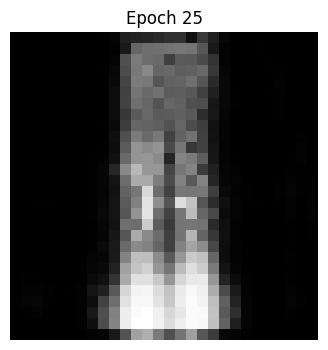

Epoch:26 Iter: 500 errD: -0.01 errG: -0.51
Epoch:26 Iter: 1000 errD: 0.00 errG: -0.50
Epoch:26 Iter: 1500 errD: -0.00 errG: -0.43
Epoch:26 Iter: 2000 errD: -0.03 errG: -0.35
Epoch:26 Iter: 2500 errD: -0.01 errG: -0.66
Epoch:26 Iter: 3000 errD: 0.00 errG: -0.60
Epoch:26 Iter: 3500 errD: 0.00 errG: -0.49


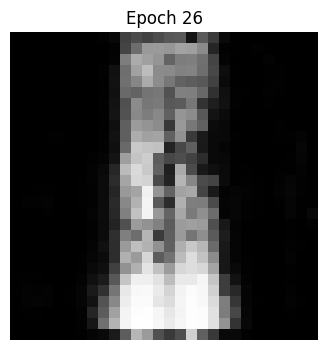

Epoch:27 Iter: 500 errD: 0.00 errG: -0.52
Epoch:27 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:27 Iter: 1500 errD: -0.00 errG: -0.50
Epoch:27 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:27 Iter: 2500 errD: -0.00 errG: -0.50
Epoch:27 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:27 Iter: 3500 errD: -0.00 errG: -0.50


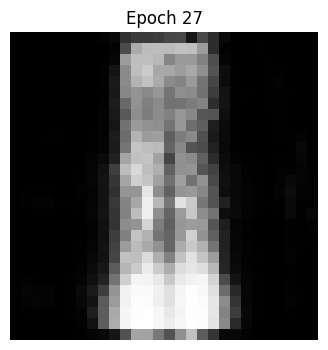

Epoch:28 Iter: 500 errD: -0.00 errG: -0.50
Epoch:28 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:28 Iter: 1500 errD: -0.00 errG: -0.50
Epoch:28 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:28 Iter: 2500 errD: -0.00 errG: -0.50
Epoch:28 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:28 Iter: 3500 errD: -0.00 errG: -0.50


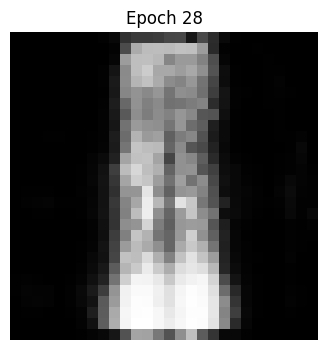

Epoch:29 Iter: 500 errD: -0.00 errG: -0.50
Epoch:29 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:29 Iter: 1500 errD: -0.00 errG: -0.50
Epoch:29 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:29 Iter: 2500 errD: -0.00 errG: -0.50
Epoch:29 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:29 Iter: 3500 errD: -0.00 errG: -0.50


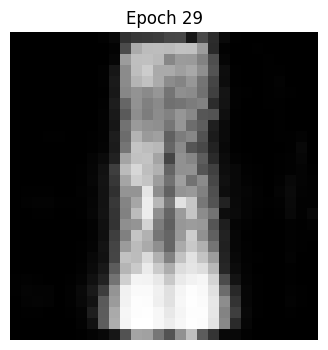

Epoch:30 Iter: 500 errD: -0.00 errG: -0.50
Epoch:30 Iter: 1000 errD: -0.00 errG: -0.50
Epoch:30 Iter: 1500 errD: -0.00 errG: -0.50
Epoch:30 Iter: 2000 errD: -0.00 errG: -0.50
Epoch:30 Iter: 2500 errD: -0.00 errG: -0.50
Epoch:30 Iter: 3000 errD: -0.00 errG: -0.50
Epoch:30 Iter: 3500 errD: -0.00 errG: -0.50


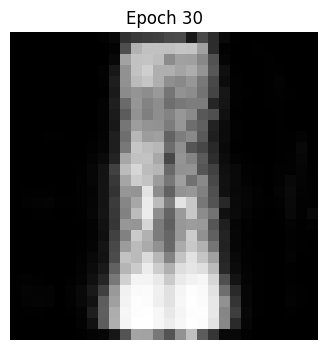

In [81]:
ERRD = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)

for epoch in range(config.num_epochs):
    for iteration, (images, cat) in enumerate(dataloader):
        #######
        # Discriminator stage: maximize E[f(x)] - E[f(G(z))]
        #######
        discriminator.zero_grad()

        input_data = images.view(images.shape[0], -1)
        output_real = discriminator(input_data).squeeze()

        noise.data.normal_(0, 1)
        fake = generator(noise)
        output_fake = discriminator(fake.detach()).squeeze()

        errD = -(torch.mean(output_real) - torch.mean(output_fake))
        ERRD[epoch] += errD.item()
        errD.backward()
        optim_D.step()

        for p in discriminator.parameters():
            p.data.clamp_(-0.01, 0.01)

        #######
        # Generator stage: minimize E[f(x)] - E[f(G(z))]
        # or
        # minimize - E[f(G(z))
        #######
        generator.zero_grad()
        output = discriminator(fake).squeeze()
        errG = -torch.mean(output)
        ERRG[epoch] += errG.item()
        errG.backward()

        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                        iteration+1,
                                                                        errD.item(),
                                                                        errG.item()))

    test_epoch_generation = generator(fixed_noise)
    plt.figure(figsize=(4, 4))
    plt.imshow(test_epoch_generation[0].detach().cpu().numpy().reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    plt.title(f'Epoch {epoch+1}')
    plt.show()

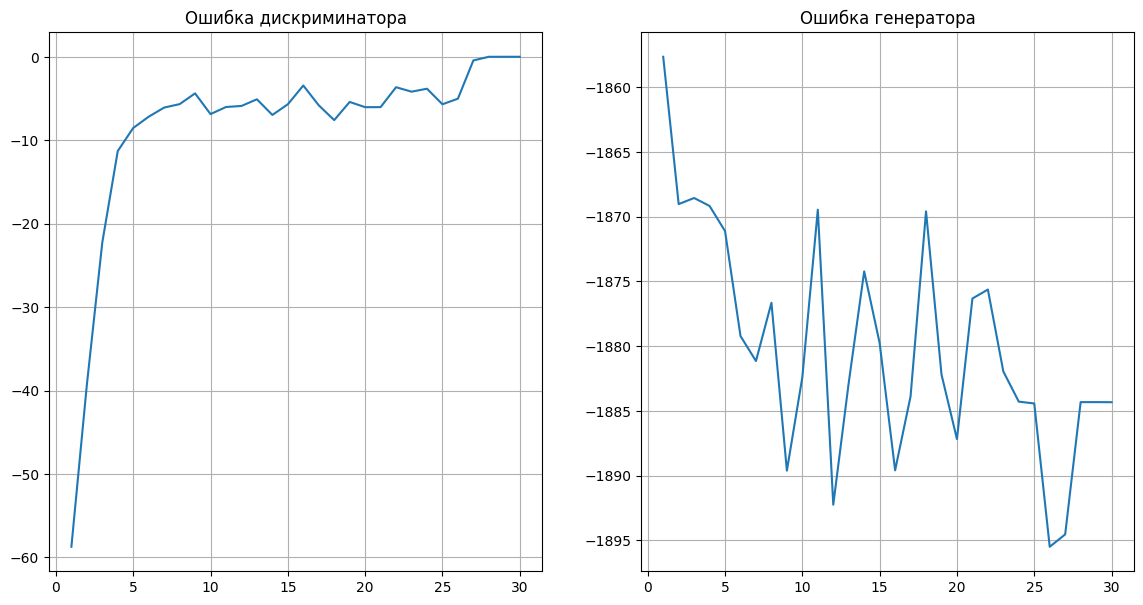

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].plot(np.arange(1, config.num_epochs + 1), ERRD)
axs[0].set_title('Ошибка дискриминатора')
axs[0].grid()

axs[1].plot(np.arange(1, config.num_epochs + 1), ERRG)
axs[1].set_title('Ошибка генератора')
axs[1].grid()

plt.show()

Обучение генератора гораздо менее стабильно, чем в случае с vanilla GAN. Weight clipping довольно плохо обеспечивает липшицевость критика.

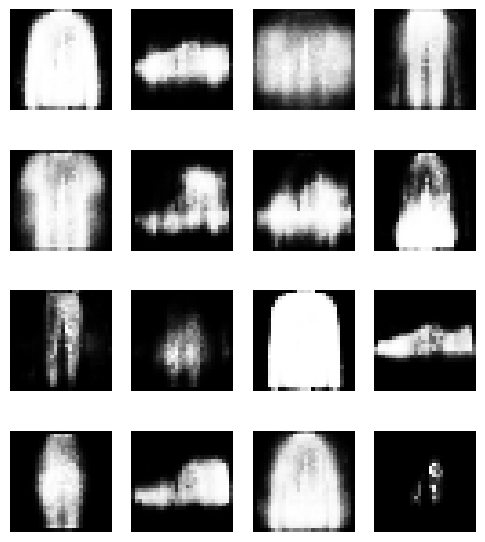

In [83]:
noise.data.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

Качество изображений хуже, чем в предыдущем эксперименте, однако теперь с большей вероятностью генерируются штаны, обувь и даже сумки.

### Gradient penalty

In [84]:
generator = Generator()
discriminator = Discriminator()

In [85]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

Epoch:1 Iter: 500 errD: 7.62 errG: -0.46
Epoch:1 Iter: 1000 errD: 6.39 errG: -0.78
Epoch:1 Iter: 1500 errD: 6.17 errG: -0.48
Epoch:1 Iter: 2000 errD: 6.39 errG: -0.44
Epoch:1 Iter: 2500 errD: 5.48 errG: -0.35
Epoch:1 Iter: 3000 errD: 7.01 errG: -0.41
Epoch:1 Iter: 3500 errD: 6.15 errG: -0.53


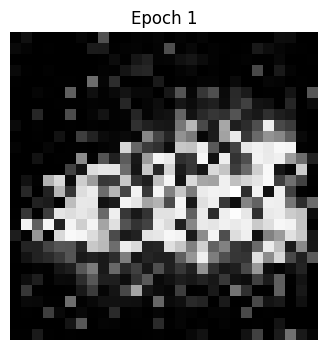

Epoch:2 Iter: 500 errD: 6.34 errG: -0.52
Epoch:2 Iter: 1000 errD: 5.37 errG: -0.50
Epoch:2 Iter: 1500 errD: 3.40 errG: -0.49
Epoch:2 Iter: 2000 errD: 2.84 errG: -0.43
Epoch:2 Iter: 2500 errD: 0.74 errG: -0.72
Epoch:2 Iter: 3000 errD: 0.44 errG: -0.38
Epoch:2 Iter: 3500 errD: 0.48 errG: -0.45


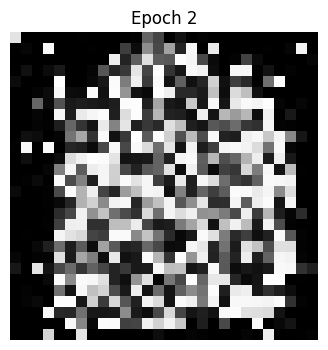

Epoch:3 Iter: 500 errD: 0.20 errG: -0.36
Epoch:3 Iter: 1000 errD: 0.74 errG: -0.50
Epoch:3 Iter: 1500 errD: 0.87 errG: -0.52
Epoch:3 Iter: 2000 errD: 0.39 errG: -0.50
Epoch:3 Iter: 2500 errD: 0.16 errG: -0.51
Epoch:3 Iter: 3000 errD: 0.24 errG: -0.48
Epoch:3 Iter: 3500 errD: 0.08 errG: -0.52


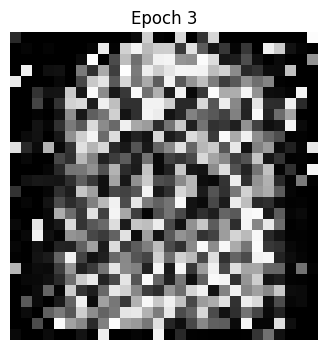

Epoch:4 Iter: 500 errD: 0.22 errG: -0.41
Epoch:4 Iter: 1000 errD: -0.24 errG: -0.33
Epoch:4 Iter: 1500 errD: 0.30 errG: -0.41
Epoch:4 Iter: 2000 errD: 0.18 errG: -0.35
Epoch:4 Iter: 2500 errD: 0.04 errG: -0.44
Epoch:4 Iter: 3000 errD: 0.55 errG: -0.43
Epoch:4 Iter: 3500 errD: -0.21 errG: -0.36


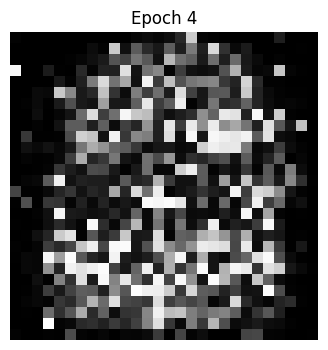

Epoch:5 Iter: 500 errD: -0.15 errG: -0.35
Epoch:5 Iter: 1000 errD: 0.24 errG: -0.40
Epoch:5 Iter: 1500 errD: 0.53 errG: -0.37
Epoch:5 Iter: 2000 errD: 0.50 errG: -0.40
Epoch:5 Iter: 2500 errD: -0.09 errG: -0.41
Epoch:5 Iter: 3000 errD: -0.19 errG: -0.40
Epoch:5 Iter: 3500 errD: 1.26 errG: -0.50


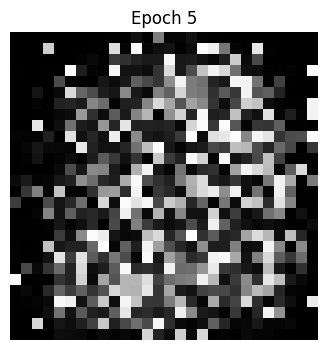

Epoch:6 Iter: 500 errD: -0.24 errG: -0.37
Epoch:6 Iter: 1000 errD: -0.21 errG: -0.36
Epoch:6 Iter: 1500 errD: -0.24 errG: -0.38
Epoch:6 Iter: 2000 errD: 0.17 errG: -0.36
Epoch:6 Iter: 2500 errD: -0.06 errG: -0.40
Epoch:6 Iter: 3000 errD: -0.39 errG: -0.32
Epoch:6 Iter: 3500 errD: -0.12 errG: -0.40


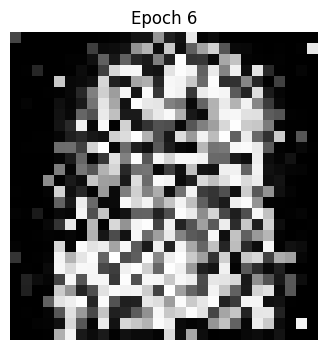

Epoch:7 Iter: 500 errD: -0.24 errG: -0.30
Epoch:7 Iter: 1000 errD: -0.30 errG: -0.32
Epoch:7 Iter: 1500 errD: -0.28 errG: -0.34
Epoch:7 Iter: 2000 errD: -0.28 errG: -0.32
Epoch:7 Iter: 2500 errD: -0.30 errG: -0.29
Epoch:7 Iter: 3000 errD: -0.43 errG: -0.33
Epoch:7 Iter: 3500 errD: -0.24 errG: -0.33


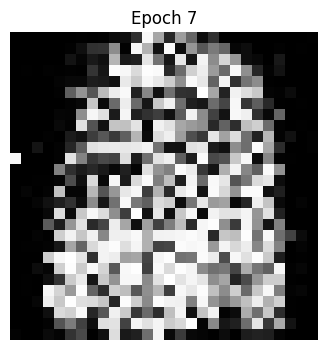

Epoch:8 Iter: 500 errD: 0.16 errG: -0.34
Epoch:8 Iter: 1000 errD: -0.20 errG: -0.36
Epoch:8 Iter: 1500 errD: -0.29 errG: -0.39
Epoch:8 Iter: 2000 errD: -0.04 errG: -0.41
Epoch:8 Iter: 2500 errD: -0.19 errG: -0.36
Epoch:8 Iter: 3000 errD: -0.24 errG: -0.41
Epoch:8 Iter: 3500 errD: -0.28 errG: -0.36


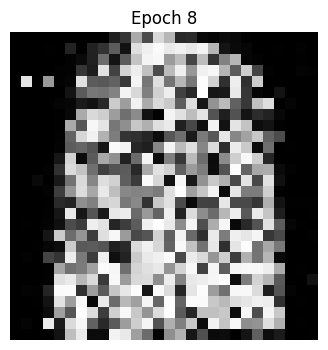

Epoch:9 Iter: 500 errD: -0.26 errG: -0.37
Epoch:9 Iter: 1000 errD: -0.25 errG: -0.40
Epoch:9 Iter: 1500 errD: -0.15 errG: -0.41
Epoch:9 Iter: 2000 errD: -0.23 errG: -0.36
Epoch:9 Iter: 2500 errD: -0.17 errG: -0.36
Epoch:9 Iter: 3000 errD: -0.18 errG: -0.36
Epoch:9 Iter: 3500 errD: -0.32 errG: -0.33


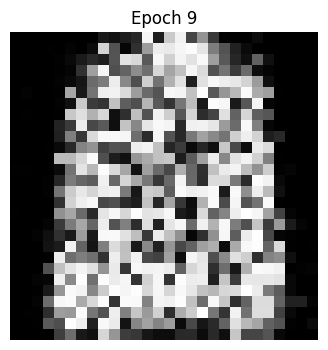

Epoch:10 Iter: 500 errD: -0.34 errG: -0.34
Epoch:10 Iter: 1000 errD: -0.10 errG: -0.32
Epoch:10 Iter: 1500 errD: -0.28 errG: -0.32
Epoch:10 Iter: 2000 errD: -0.24 errG: -0.29
Epoch:10 Iter: 2500 errD: -0.17 errG: -0.39
Epoch:10 Iter: 3000 errD: -0.29 errG: -0.39
Epoch:10 Iter: 3500 errD: -0.17 errG: -0.35


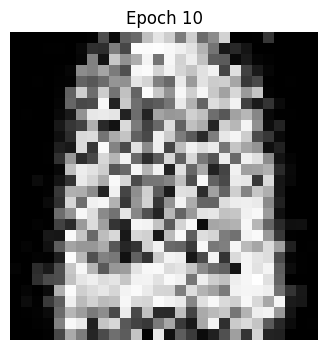

Epoch:11 Iter: 500 errD: -0.24 errG: -0.31
Epoch:11 Iter: 1000 errD: -0.22 errG: -0.36
Epoch:11 Iter: 1500 errD: -0.18 errG: -0.36
Epoch:11 Iter: 2000 errD: -0.17 errG: -0.34
Epoch:11 Iter: 2500 errD: -0.07 errG: -0.33
Epoch:11 Iter: 3000 errD: -0.24 errG: -0.33
Epoch:11 Iter: 3500 errD: -0.22 errG: -0.35


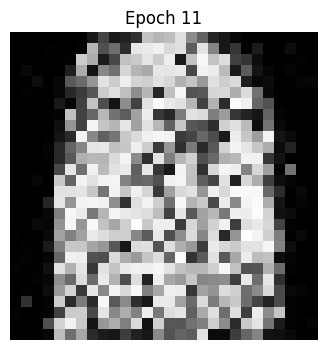

Epoch:12 Iter: 500 errD: -0.26 errG: -0.29
Epoch:12 Iter: 1000 errD: -0.13 errG: -0.42
Epoch:12 Iter: 1500 errD: -0.36 errG: -0.34
Epoch:12 Iter: 2000 errD: -0.32 errG: -0.38
Epoch:12 Iter: 2500 errD: -0.22 errG: -0.44
Epoch:12 Iter: 3000 errD: -0.21 errG: -0.39
Epoch:12 Iter: 3500 errD: -0.21 errG: -0.44


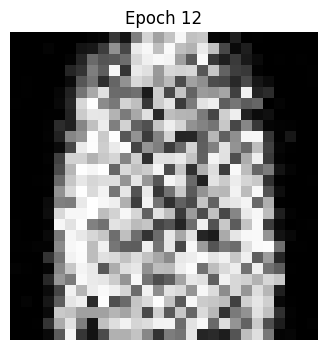

Epoch:13 Iter: 500 errD: -0.24 errG: -0.39
Epoch:13 Iter: 1000 errD: -0.25 errG: -0.42
Epoch:13 Iter: 1500 errD: -0.16 errG: -0.42
Epoch:13 Iter: 2000 errD: -0.25 errG: -0.39
Epoch:13 Iter: 2500 errD: -0.18 errG: -0.38
Epoch:13 Iter: 3000 errD: -0.22 errG: -0.38
Epoch:13 Iter: 3500 errD: -0.11 errG: -0.35


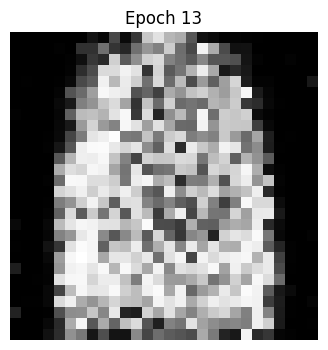

Epoch:14 Iter: 500 errD: -0.20 errG: -0.37
Epoch:14 Iter: 1000 errD: -0.19 errG: -0.42
Epoch:14 Iter: 1500 errD: -0.06 errG: -0.43
Epoch:14 Iter: 2000 errD: -0.16 errG: -0.42
Epoch:14 Iter: 2500 errD: -0.04 errG: -0.42
Epoch:14 Iter: 3000 errD: -0.15 errG: -0.41
Epoch:14 Iter: 3500 errD: -0.14 errG: -0.43


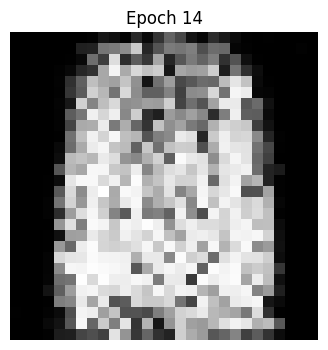

Epoch:15 Iter: 500 errD: -0.24 errG: -0.41
Epoch:15 Iter: 1000 errD: -0.34 errG: -0.31
Epoch:15 Iter: 1500 errD: -0.09 errG: -0.45
Epoch:15 Iter: 2000 errD: -0.15 errG: -0.41
Epoch:15 Iter: 2500 errD: 0.03 errG: -0.44
Epoch:15 Iter: 3000 errD: -0.15 errG: -0.38
Epoch:15 Iter: 3500 errD: -0.11 errG: -0.43


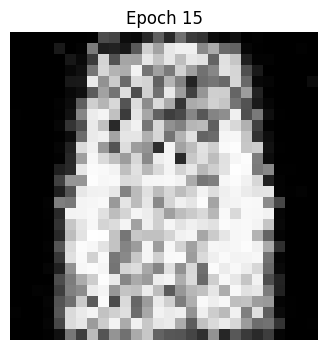

Epoch:16 Iter: 500 errD: -0.18 errG: -0.33
Epoch:16 Iter: 1000 errD: -0.13 errG: -0.51
Epoch:16 Iter: 1500 errD: -0.15 errG: -0.41
Epoch:16 Iter: 2000 errD: -0.15 errG: -0.40
Epoch:16 Iter: 2500 errD: -0.12 errG: -0.43
Epoch:16 Iter: 3000 errD: -0.20 errG: -0.42
Epoch:16 Iter: 3500 errD: -0.20 errG: -0.38


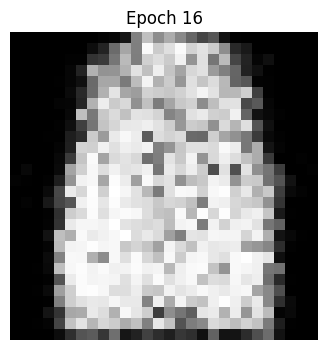

Epoch:17 Iter: 500 errD: -0.18 errG: -0.44
Epoch:17 Iter: 1000 errD: -0.19 errG: -0.43
Epoch:17 Iter: 1500 errD: 0.13 errG: -0.51
Epoch:17 Iter: 2000 errD: -0.15 errG: -0.45
Epoch:17 Iter: 2500 errD: -0.11 errG: -0.47
Epoch:17 Iter: 3000 errD: -0.22 errG: -0.40
Epoch:17 Iter: 3500 errD: -0.12 errG: -0.42


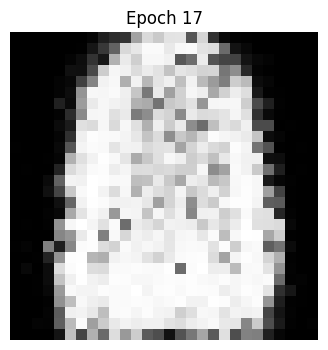

Epoch:18 Iter: 500 errD: -0.27 errG: -0.37
Epoch:18 Iter: 1000 errD: -0.15 errG: -0.35
Epoch:18 Iter: 1500 errD: -0.15 errG: -0.45
Epoch:18 Iter: 2000 errD: -0.21 errG: -0.36
Epoch:18 Iter: 2500 errD: -0.20 errG: -0.45
Epoch:18 Iter: 3000 errD: -0.21 errG: -0.39
Epoch:18 Iter: 3500 errD: -0.09 errG: -0.48


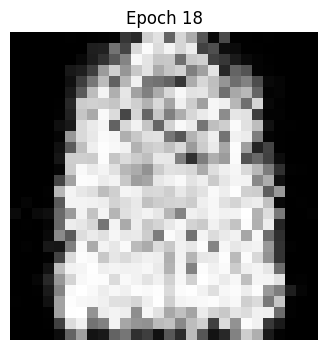

Epoch:19 Iter: 500 errD: -0.27 errG: -0.41
Epoch:19 Iter: 1000 errD: -0.17 errG: -0.38
Epoch:19 Iter: 1500 errD: -0.06 errG: -0.52
Epoch:19 Iter: 2000 errD: -0.20 errG: -0.41
Epoch:19 Iter: 2500 errD: -0.19 errG: -0.41
Epoch:19 Iter: 3000 errD: -0.19 errG: -0.44
Epoch:19 Iter: 3500 errD: -0.16 errG: -0.44


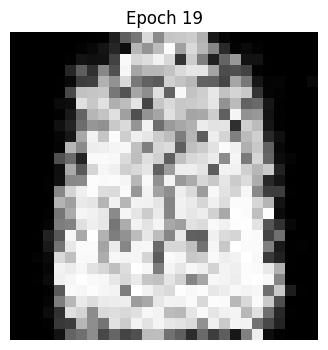

Epoch:20 Iter: 500 errD: -0.14 errG: -0.45
Epoch:20 Iter: 1000 errD: -0.20 errG: -0.35
Epoch:20 Iter: 1500 errD: -0.18 errG: -0.39
Epoch:20 Iter: 2000 errD: -0.21 errG: -0.37
Epoch:20 Iter: 2500 errD: -0.13 errG: -0.35
Epoch:20 Iter: 3000 errD: -0.15 errG: -0.43
Epoch:20 Iter: 3500 errD: 0.03 errG: -0.45


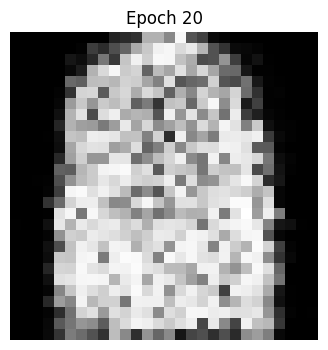

Epoch:21 Iter: 500 errD: -0.14 errG: -0.41
Epoch:21 Iter: 1000 errD: -0.18 errG: -0.34
Epoch:21 Iter: 1500 errD: -0.10 errG: -0.43
Epoch:21 Iter: 2000 errD: -0.18 errG: -0.38
Epoch:21 Iter: 2500 errD: -0.20 errG: -0.41
Epoch:21 Iter: 3000 errD: -0.05 errG: -0.46
Epoch:21 Iter: 3500 errD: -0.19 errG: -0.36


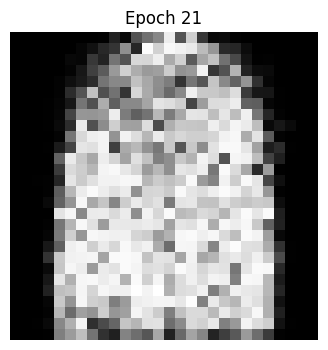

Epoch:22 Iter: 500 errD: -0.19 errG: -0.37
Epoch:22 Iter: 1000 errD: -0.21 errG: -0.45
Epoch:22 Iter: 1500 errD: -0.25 errG: -0.37
Epoch:22 Iter: 2000 errD: -0.16 errG: -0.49
Epoch:22 Iter: 2500 errD: -0.21 errG: -0.43
Epoch:22 Iter: 3000 errD: -0.08 errG: -0.50
Epoch:22 Iter: 3500 errD: 0.03 errG: -0.39


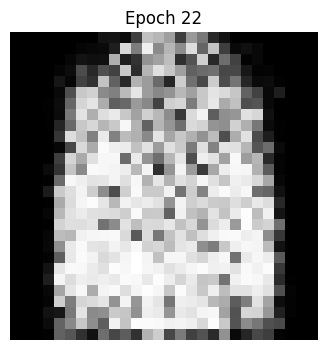

Epoch:23 Iter: 500 errD: -0.17 errG: -0.47
Epoch:23 Iter: 1000 errD: -0.13 errG: -0.48
Epoch:23 Iter: 1500 errD: -0.16 errG: -0.46
Epoch:23 Iter: 2000 errD: -0.22 errG: -0.32
Epoch:23 Iter: 2500 errD: -0.24 errG: -0.41
Epoch:23 Iter: 3000 errD: -0.18 errG: -0.39
Epoch:23 Iter: 3500 errD: -0.16 errG: -0.45


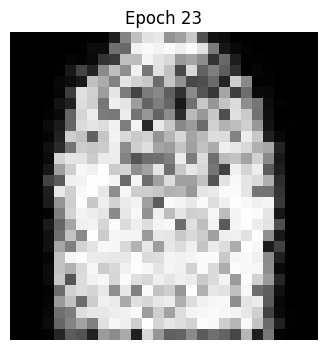

Epoch:24 Iter: 500 errD: -0.02 errG: -0.47
Epoch:24 Iter: 1000 errD: -0.07 errG: -0.44
Epoch:24 Iter: 1500 errD: -0.13 errG: -0.41
Epoch:24 Iter: 2000 errD: -0.13 errG: -0.43
Epoch:24 Iter: 2500 errD: -0.02 errG: -0.51
Epoch:24 Iter: 3000 errD: -0.21 errG: -0.45
Epoch:24 Iter: 3500 errD: -0.19 errG: -0.39


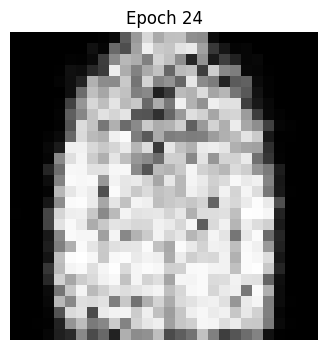

Epoch:25 Iter: 500 errD: -0.16 errG: -0.42
Epoch:25 Iter: 1000 errD: -0.17 errG: -0.42
Epoch:25 Iter: 1500 errD: -0.04 errG: -0.45
Epoch:25 Iter: 2000 errD: -0.19 errG: -0.37
Epoch:25 Iter: 2500 errD: -0.09 errG: -0.54
Epoch:25 Iter: 3000 errD: -0.20 errG: -0.42
Epoch:25 Iter: 3500 errD: -0.14 errG: -0.45


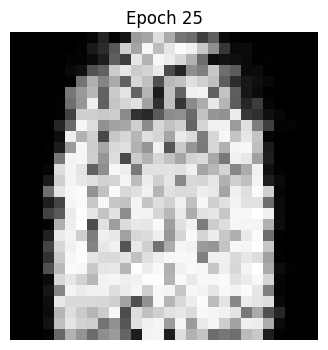

Epoch:26 Iter: 500 errD: -0.05 errG: -0.44
Epoch:26 Iter: 1000 errD: -0.18 errG: -0.41
Epoch:26 Iter: 1500 errD: -0.20 errG: -0.45
Epoch:26 Iter: 2000 errD: -0.07 errG: -0.51
Epoch:26 Iter: 2500 errD: -0.17 errG: -0.45
Epoch:26 Iter: 3000 errD: -0.09 errG: -0.45
Epoch:26 Iter: 3500 errD: -0.09 errG: -0.43


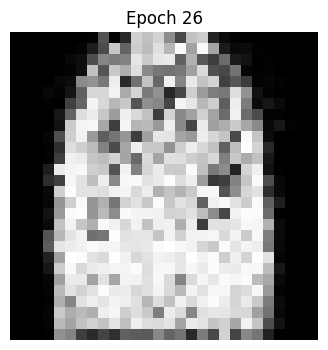

Epoch:27 Iter: 500 errD: -0.19 errG: -0.42
Epoch:27 Iter: 1000 errD: -0.14 errG: -0.44
Epoch:27 Iter: 1500 errD: -0.14 errG: -0.46
Epoch:27 Iter: 2000 errD: -0.21 errG: -0.37
Epoch:27 Iter: 2500 errD: -0.13 errG: -0.46
Epoch:27 Iter: 3000 errD: -0.15 errG: -0.48
Epoch:27 Iter: 3500 errD: -0.07 errG: -0.42


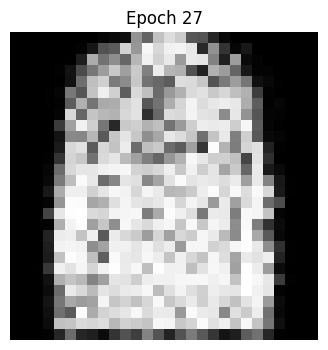

Epoch:28 Iter: 500 errD: -0.15 errG: -0.41
Epoch:28 Iter: 1000 errD: -0.07 errG: -0.37
Epoch:28 Iter: 1500 errD: -0.22 errG: -0.40
Epoch:28 Iter: 2000 errD: -0.10 errG: -0.42
Epoch:28 Iter: 2500 errD: -0.21 errG: -0.37
Epoch:28 Iter: 3000 errD: -0.25 errG: -0.40
Epoch:28 Iter: 3500 errD: -0.16 errG: -0.38


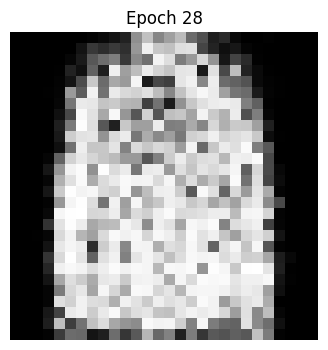

Epoch:29 Iter: 500 errD: -0.21 errG: -0.41
Epoch:29 Iter: 1000 errD: -0.23 errG: -0.39
Epoch:29 Iter: 1500 errD: -0.15 errG: -0.39
Epoch:29 Iter: 2000 errD: -0.09 errG: -0.42
Epoch:29 Iter: 2500 errD: -0.11 errG: -0.46
Epoch:29 Iter: 3000 errD: -0.15 errG: -0.41
Epoch:29 Iter: 3500 errD: -0.14 errG: -0.39


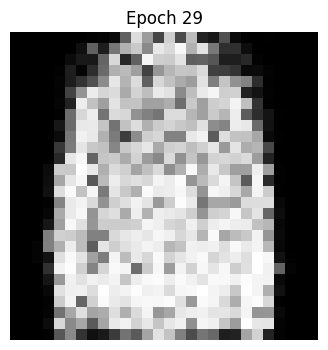

Epoch:30 Iter: 500 errD: -0.01 errG: -0.45
Epoch:30 Iter: 1000 errD: -0.11 errG: -0.48
Epoch:30 Iter: 1500 errD: -0.16 errG: -0.49
Epoch:30 Iter: 2000 errD: -0.16 errG: -0.45
Epoch:30 Iter: 2500 errD: -0.02 errG: -0.45
Epoch:30 Iter: 3000 errD: -0.19 errG: -0.43
Epoch:30 Iter: 3500 errD: -0.13 errG: -0.49


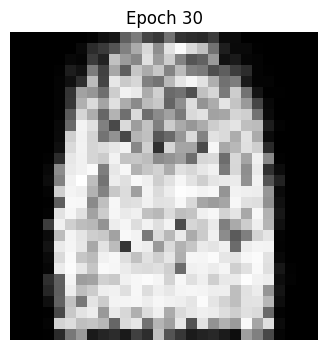

In [86]:
ERRD = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)

for epoch in range(config.num_epochs):
    for iteration, (images, _) in enumerate(dataloader):
        #######
        # Discriminator stage: maximize E[f(x)] - E[f(G(z))]
        # with gradient penalty: lambda*(||grad(f(interpolated))||- 1)^2
        # minimize -E[f(x)] + E[f(G(z))] + lambda*(||grad(f(interpolated))||- 1)^2
        #######
        discriminator.zero_grad()

        input_data = images.view(images.shape[0], -1)
        output_real = discriminator(input_data).squeeze()

        noise.data.normal_(0, 1)
        fake = generator(noise)
        output_fake = discriminator(fake.detach()).squeeze()

        errD_base = -(torch.mean(output_real) - torch.mean(output_fake))

        # Gradient Penalty
        lambda_gp = 10
        batch_size = input_data.size(0)

        epsilon = torch.rand(batch_size, 1, device=input_data.device)
        interpolated = epsilon * input_data + (1 - epsilon) * fake.detach()

        interpolated.requires_grad_(True)
        output_interpolated = discriminator(interpolated).squeeze()

        gradients = torch.autograd.grad(
            outputs=output_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(output_interpolated),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]

        gradients_norm = gradients.view(gradients.size(0), -1).norm(2, dim=1)
        gradient_penalty = ((gradients_norm - 1) ** 2).mean()
        errD = errD_base + lambda_gp * gradient_penalty

        ERRD[epoch] += errD.item()
        errD.backward()
        optim_D.step()

        #######
        # Generator stage: minimize -E[f(G(z))]
        #######
        generator.zero_grad()
        output_fake_for_g = discriminator(fake).squeeze()
        errG = -torch.mean(output_fake_for_g)
        ERRG[epoch] += errG.item()
        errG.backward()
        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                       iteration+1,
                                                                       errD.item(),
                                                                       errG.item()))

    # Генерация тестового изображения
    test_epoch_generation = generator(fixed_noise)
    plt.figure(figsize=(4, 4))
    plt.imshow(test_epoch_generation[0].detach().cpu().numpy().reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    plt.title(f'Epoch {epoch+1}')
    plt.show()

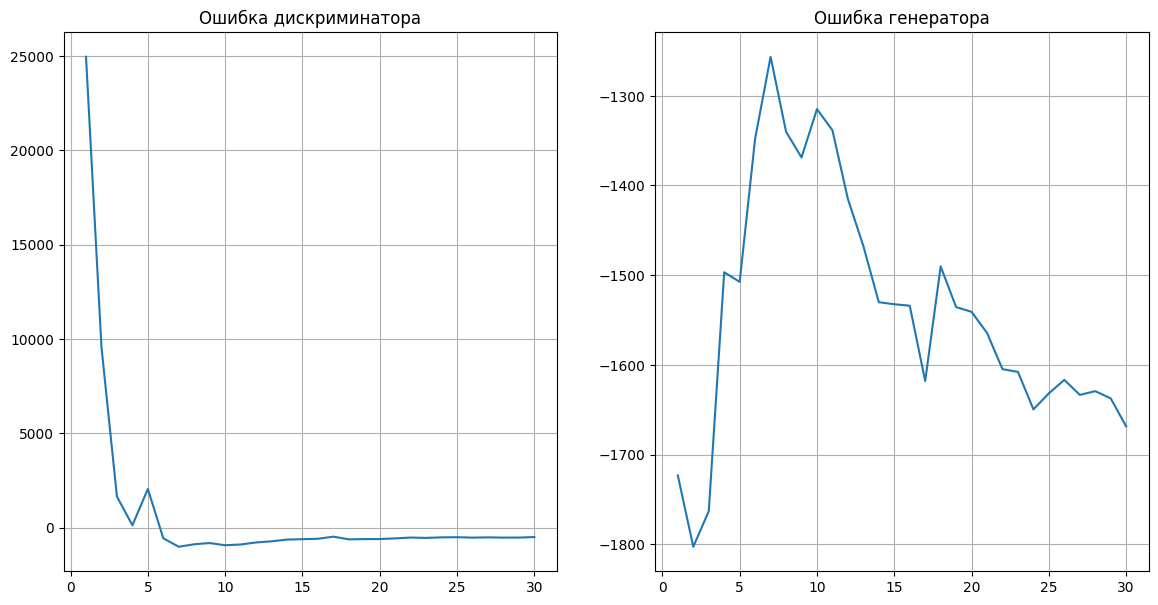

In [87]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].plot(np.arange(1, config.num_epochs + 1), ERRD)
axs[0].set_title('Ошибка дискриминатора')
axs[0].grid()

axs[1].plot(np.arange(1, config.num_epochs + 1), ERRG)
axs[1].set_title('Ошибка генератора')
axs[1].grid()

plt.show()

Из графиков обучения видно, что в течение первых ~7 эпох ошибка генератора стремительно растет, что на первый взгяд является плохим признаком. Однако также до 7 эпохи стремительно падает ошибка дискриминатора, а затем резко перестает. Из этого можно сделать вывод, что в течение этого начального периода обучения дискриминатор обучается быть 1-Липшицевым, а функция потерь становится приближенной формулой расстояния Вассерштейна. После 7 эпохи ошибка дискриминатора начинает изменяться очень плавно, а ошибка генератора достаточно стабильно уменьшается. Именно с этого этапа обучения генератор начинает обучаться минимизировать "правильный" лосс, и генерация становится лучше.

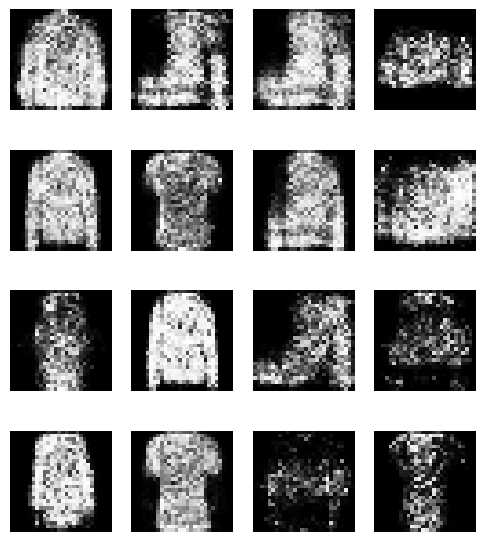

In [88]:
noise.data.normal_(0, 1)
fake = generator(noise)

plt.figure(figsize=(6, 7))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.axis('off')

Визуально качество генерации за те же 30 эпох обучения ухудшилось, однако, учитывая изменение ошибок генератора и критика во время обучения, можно предположить, что в перспективе (при более длительном обучении) gradient penalty обеспечит лучшее качество по сравнению с weight clipping.

## cWGAN

Построим conditional WGAN на основе предыдущей (безусловной) модели WGAN с gradient penalty.

In [25]:
num_classes = 10

In [26]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(config.noise_size + num_classes, 200), # Плюс num_classes входных значений - one-hot метка класса
            nn.ReLU(inplace=True),
            nn.Linear(200, 28*28),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28 + num_classes, 200), # Плюс num_classes входных значений - one-hot метка класса
            nn.ReLU(inplace=True),
            nn.Linear(200, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 1),
            nn.Sigmoid())

    def forward(self, x):
        return self.model(x)

In [27]:
generator = Generator()
discriminator = Discriminator()

In [28]:
optim_G = optim.Adam(params=generator.parameters(), lr=0.0001)
optim_D = optim.Adam(params=discriminator.parameters(), lr=0.0001)

In [29]:
fixed_example_label = 2
fixed_label_onehot = torch.nn.functional.one_hot(torch.tensor([fixed_example_label]), num_classes=num_classes).float()

Epoch:1 Iter: 500 errD: 8.15 errG: -0.59
Epoch:1 Iter: 1000 errD: 6.12 errG: -0.52
Epoch:1 Iter: 1500 errD: 6.28 errG: -0.57
Epoch:1 Iter: 2000 errD: 7.42 errG: -0.36
Epoch:1 Iter: 2500 errD: 8.72 errG: -0.49
Epoch:1 Iter: 3000 errD: 8.34 errG: -0.49
Epoch:1 Iter: 3500 errD: 4.56 errG: -0.68


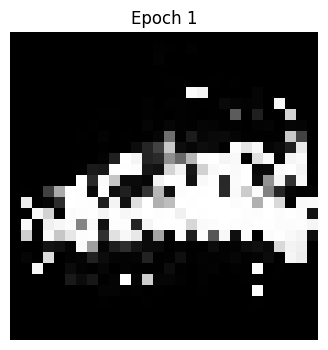

Epoch:2 Iter: 500 errD: 2.60 errG: -0.42
Epoch:2 Iter: 1000 errD: 4.22 errG: -0.39
Epoch:2 Iter: 1500 errD: 2.97 errG: -0.49
Epoch:2 Iter: 2000 errD: 2.86 errG: -0.49
Epoch:2 Iter: 2500 errD: 1.57 errG: -0.65
Epoch:2 Iter: 3000 errD: 0.77 errG: -0.53
Epoch:2 Iter: 3500 errD: 0.28 errG: -0.33


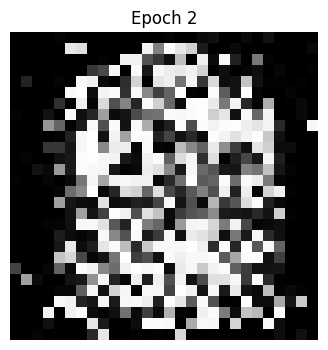

Epoch:3 Iter: 500 errD: -0.01 errG: -0.40
Epoch:3 Iter: 1000 errD: 0.10 errG: -0.48
Epoch:3 Iter: 1500 errD: 0.09 errG: -0.38
Epoch:3 Iter: 2000 errD: 0.28 errG: -0.44
Epoch:3 Iter: 2500 errD: 0.10 errG: -0.33
Epoch:3 Iter: 3000 errD: -0.08 errG: -0.36
Epoch:3 Iter: 3500 errD: -0.10 errG: -0.34


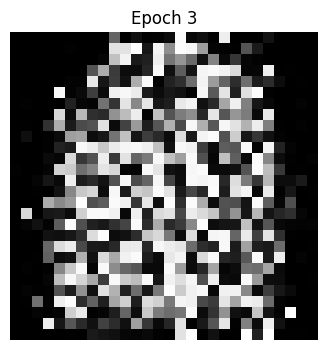

Epoch:4 Iter: 500 errD: -0.03 errG: -0.38
Epoch:4 Iter: 1000 errD: -0.33 errG: -0.38
Epoch:4 Iter: 1500 errD: 0.11 errG: -0.37
Epoch:4 Iter: 2000 errD: 0.03 errG: -0.51
Epoch:4 Iter: 2500 errD: -0.24 errG: -0.35
Epoch:4 Iter: 3000 errD: -0.06 errG: -0.48
Epoch:4 Iter: 3500 errD: -0.03 errG: -0.48


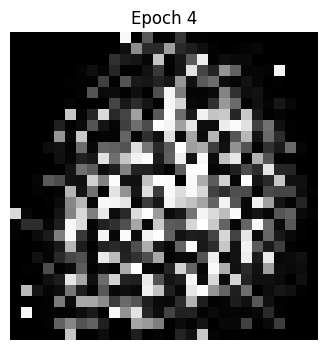

Epoch:5 Iter: 500 errD: -0.29 errG: -0.41
Epoch:5 Iter: 1000 errD: -0.14 errG: -0.37
Epoch:5 Iter: 1500 errD: -0.24 errG: -0.38
Epoch:5 Iter: 2000 errD: -0.04 errG: -0.35
Epoch:5 Iter: 2500 errD: -0.12 errG: -0.30
Epoch:5 Iter: 3000 errD: -0.32 errG: -0.28
Epoch:5 Iter: 3500 errD: -0.33 errG: -0.32


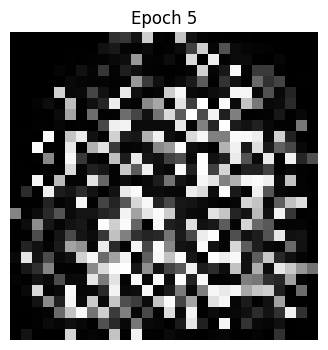

Epoch:6 Iter: 500 errD: -0.24 errG: -0.27
Epoch:6 Iter: 1000 errD: -0.32 errG: -0.38
Epoch:6 Iter: 1500 errD: -0.20 errG: -0.32
Epoch:6 Iter: 2000 errD: -0.23 errG: -0.28
Epoch:6 Iter: 2500 errD: -0.12 errG: -0.31
Epoch:6 Iter: 3000 errD: -0.26 errG: -0.40
Epoch:6 Iter: 3500 errD: -0.26 errG: -0.34


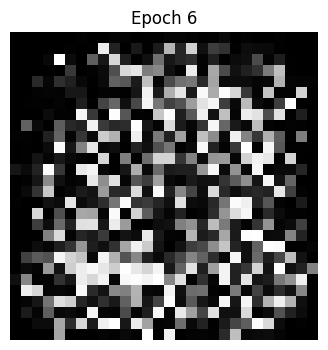

Epoch:7 Iter: 500 errD: -0.41 errG: -0.28
Epoch:7 Iter: 1000 errD: -0.20 errG: -0.27
Epoch:7 Iter: 1500 errD: -0.25 errG: -0.33
Epoch:7 Iter: 2000 errD: -0.15 errG: -0.30
Epoch:7 Iter: 2500 errD: -0.21 errG: -0.30
Epoch:7 Iter: 3000 errD: -0.27 errG: -0.34
Epoch:7 Iter: 3500 errD: -0.30 errG: -0.31


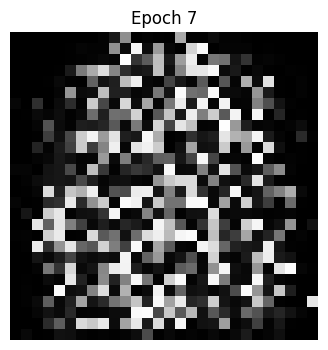

Epoch:8 Iter: 500 errD: -0.29 errG: -0.31
Epoch:8 Iter: 1000 errD: -0.08 errG: -0.36
Epoch:8 Iter: 1500 errD: -0.33 errG: -0.28
Epoch:8 Iter: 2000 errD: -0.32 errG: -0.32
Epoch:8 Iter: 2500 errD: -0.36 errG: -0.31
Epoch:8 Iter: 3000 errD: -0.26 errG: -0.34
Epoch:8 Iter: 3500 errD: -0.41 errG: -0.32


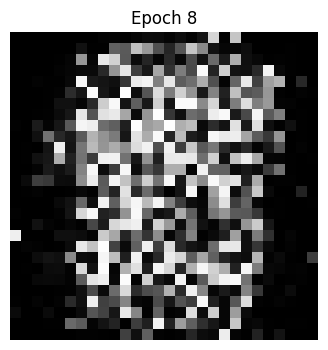

Epoch:9 Iter: 500 errD: -0.34 errG: -0.33
Epoch:9 Iter: 1000 errD: -0.27 errG: -0.32
Epoch:9 Iter: 1500 errD: -0.32 errG: -0.28
Epoch:9 Iter: 2000 errD: -0.19 errG: -0.32
Epoch:9 Iter: 2500 errD: -0.21 errG: -0.37
Epoch:9 Iter: 3000 errD: -0.06 errG: -0.33
Epoch:9 Iter: 3500 errD: -0.24 errG: -0.42


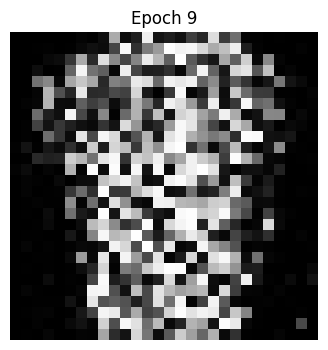

Epoch:10 Iter: 500 errD: -0.17 errG: -0.41
Epoch:10 Iter: 1000 errD: 0.05 errG: -0.42
Epoch:10 Iter: 1500 errD: -0.29 errG: -0.38
Epoch:10 Iter: 2000 errD: -0.20 errG: -0.39
Epoch:10 Iter: 2500 errD: -0.17 errG: -0.42
Epoch:10 Iter: 3000 errD: -0.19 errG: -0.35
Epoch:10 Iter: 3500 errD: -0.06 errG: -0.46


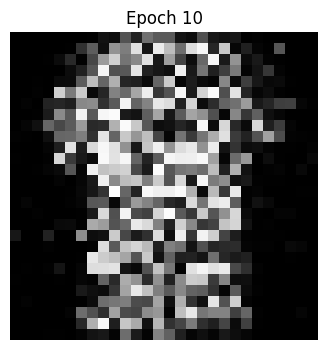

Epoch:11 Iter: 500 errD: -0.27 errG: -0.41
Epoch:11 Iter: 1000 errD: -0.21 errG: -0.38
Epoch:11 Iter: 1500 errD: -0.10 errG: -0.38
Epoch:11 Iter: 2000 errD: 0.02 errG: -0.39
Epoch:11 Iter: 2500 errD: -0.32 errG: -0.38
Epoch:11 Iter: 3000 errD: -0.13 errG: -0.39
Epoch:11 Iter: 3500 errD: -0.11 errG: -0.37


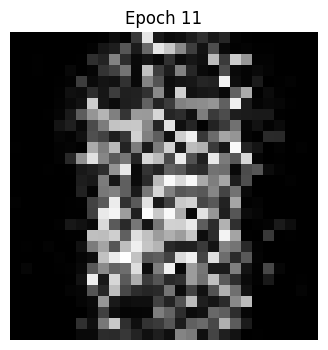

Epoch:12 Iter: 500 errD: -0.15 errG: -0.43
Epoch:12 Iter: 1000 errD: -0.14 errG: -0.37
Epoch:12 Iter: 1500 errD: -0.16 errG: -0.37
Epoch:12 Iter: 2000 errD: -0.22 errG: -0.41
Epoch:12 Iter: 2500 errD: -0.13 errG: -0.41
Epoch:12 Iter: 3000 errD: -0.16 errG: -0.42
Epoch:12 Iter: 3500 errD: -0.17 errG: -0.46


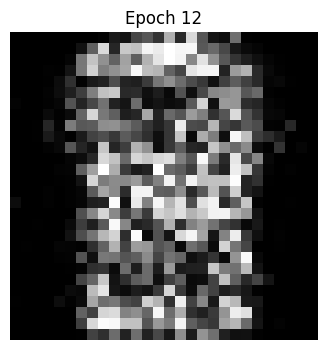

Epoch:13 Iter: 500 errD: -0.21 errG: -0.34
Epoch:13 Iter: 1000 errD: -0.19 errG: -0.41
Epoch:13 Iter: 1500 errD: -0.32 errG: -0.33
Epoch:13 Iter: 2000 errD: -0.20 errG: -0.36
Epoch:13 Iter: 2500 errD: -0.19 errG: -0.42
Epoch:13 Iter: 3000 errD: -0.22 errG: -0.35
Epoch:13 Iter: 3500 errD: -0.23 errG: -0.40


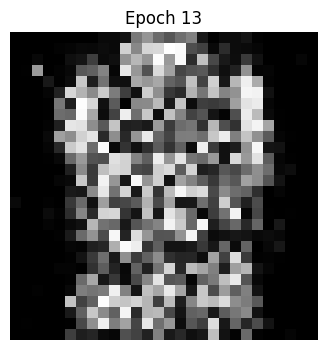

Epoch:14 Iter: 500 errD: -0.19 errG: -0.39
Epoch:14 Iter: 1000 errD: -0.13 errG: -0.43
Epoch:14 Iter: 1500 errD: -0.08 errG: -0.46
Epoch:14 Iter: 2000 errD: -0.19 errG: -0.39
Epoch:14 Iter: 2500 errD: -0.11 errG: -0.37
Epoch:14 Iter: 3000 errD: -0.19 errG: -0.33
Epoch:14 Iter: 3500 errD: -0.23 errG: -0.37


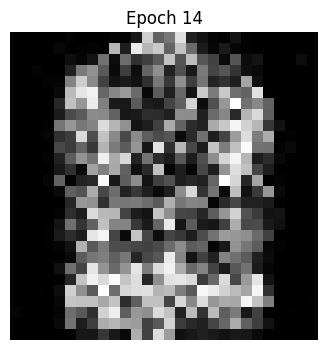

Epoch:15 Iter: 500 errD: -0.10 errG: -0.45
Epoch:15 Iter: 1000 errD: -0.18 errG: -0.40
Epoch:15 Iter: 1500 errD: -0.03 errG: -0.41
Epoch:15 Iter: 2000 errD: -0.11 errG: -0.41
Epoch:15 Iter: 2500 errD: -0.14 errG: -0.42
Epoch:15 Iter: 3000 errD: -0.14 errG: -0.43
Epoch:15 Iter: 3500 errD: -0.14 errG: -0.38


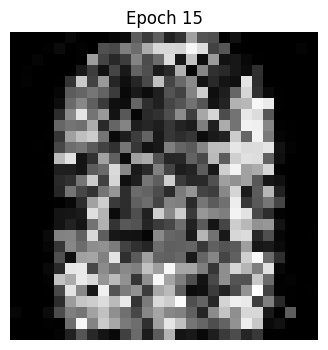

Epoch:16 Iter: 500 errD: -0.12 errG: -0.40
Epoch:16 Iter: 1000 errD: -0.13 errG: -0.40
Epoch:16 Iter: 1500 errD: -0.01 errG: -0.45
Epoch:16 Iter: 2000 errD: -0.15 errG: -0.42
Epoch:16 Iter: 2500 errD: -0.18 errG: -0.42
Epoch:16 Iter: 3000 errD: -0.14 errG: -0.45
Epoch:16 Iter: 3500 errD: 0.16 errG: -0.43


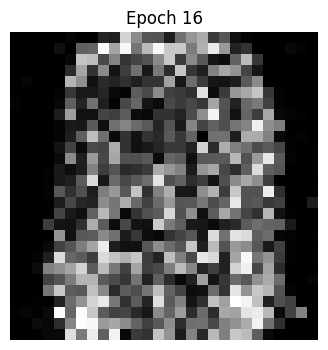

Epoch:17 Iter: 500 errD: -0.11 errG: -0.39
Epoch:17 Iter: 1000 errD: -0.14 errG: -0.38
Epoch:17 Iter: 1500 errD: -0.15 errG: -0.36
Epoch:17 Iter: 2000 errD: -0.17 errG: -0.36
Epoch:17 Iter: 2500 errD: -0.11 errG: -0.36
Epoch:17 Iter: 3000 errD: -0.13 errG: -0.36
Epoch:17 Iter: 3500 errD: -0.20 errG: -0.38


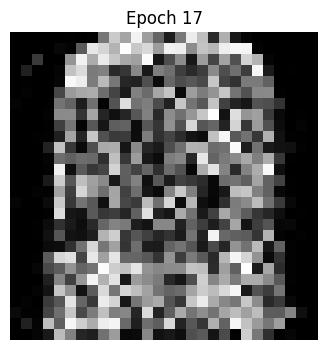

Epoch:18 Iter: 500 errD: -0.14 errG: -0.40
Epoch:18 Iter: 1000 errD: -0.14 errG: -0.49
Epoch:18 Iter: 1500 errD: -0.14 errG: -0.41
Epoch:18 Iter: 2000 errD: -0.12 errG: -0.39
Epoch:18 Iter: 2500 errD: -0.18 errG: -0.42
Epoch:18 Iter: 3000 errD: -0.08 errG: -0.41
Epoch:18 Iter: 3500 errD: -0.11 errG: -0.43


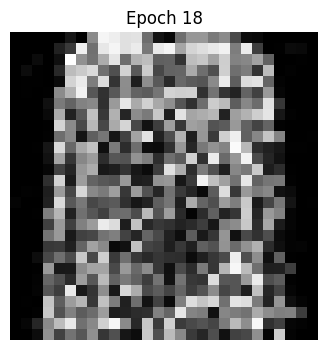

Epoch:19 Iter: 500 errD: -0.19 errG: -0.43
Epoch:19 Iter: 1000 errD: -0.15 errG: -0.45
Epoch:19 Iter: 1500 errD: -0.10 errG: -0.35
Epoch:19 Iter: 2000 errD: -0.10 errG: -0.45
Epoch:19 Iter: 2500 errD: -0.10 errG: -0.41
Epoch:19 Iter: 3000 errD: -0.16 errG: -0.39
Epoch:19 Iter: 3500 errD: -0.08 errG: -0.47


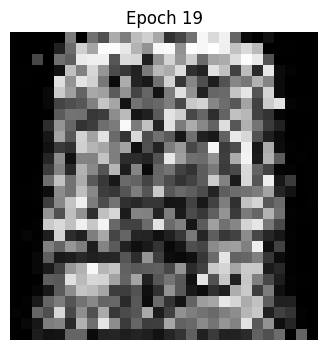

Epoch:20 Iter: 500 errD: -0.11 errG: -0.40
Epoch:20 Iter: 1000 errD: -0.08 errG: -0.47
Epoch:20 Iter: 1500 errD: -0.02 errG: -0.48
Epoch:20 Iter: 2000 errD: -0.05 errG: -0.42
Epoch:20 Iter: 2500 errD: -0.17 errG: -0.42
Epoch:20 Iter: 3000 errD: -0.10 errG: -0.46
Epoch:20 Iter: 3500 errD: -0.15 errG: -0.42


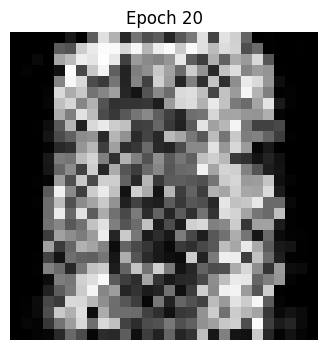

Epoch:21 Iter: 500 errD: -0.09 errG: -0.36
Epoch:21 Iter: 1000 errD: -0.11 errG: -0.42
Epoch:21 Iter: 1500 errD: -0.12 errG: -0.39
Epoch:21 Iter: 2000 errD: -0.01 errG: -0.44
Epoch:21 Iter: 2500 errD: -0.15 errG: -0.42
Epoch:21 Iter: 3000 errD: -0.14 errG: -0.45
Epoch:21 Iter: 3500 errD: -0.07 errG: -0.44


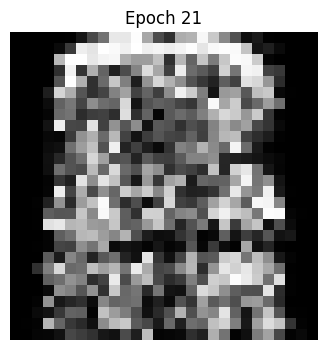

Epoch:22 Iter: 500 errD: -0.11 errG: -0.42
Epoch:22 Iter: 1000 errD: -0.14 errG: -0.40
Epoch:22 Iter: 1500 errD: -0.15 errG: -0.36
Epoch:22 Iter: 2000 errD: -0.09 errG: -0.40
Epoch:22 Iter: 2500 errD: -0.09 errG: -0.44
Epoch:22 Iter: 3000 errD: -0.09 errG: -0.39
Epoch:22 Iter: 3500 errD: -0.18 errG: -0.40


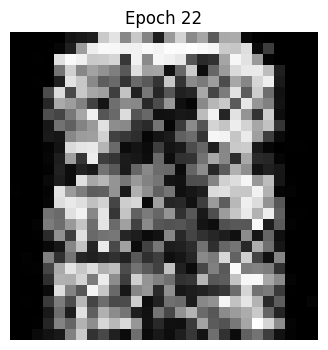

Epoch:23 Iter: 500 errD: -0.10 errG: -0.44
Epoch:23 Iter: 1000 errD: -0.08 errG: -0.46
Epoch:23 Iter: 1500 errD: -0.07 errG: -0.43
Epoch:23 Iter: 2000 errD: -0.14 errG: -0.42
Epoch:23 Iter: 2500 errD: -0.07 errG: -0.44
Epoch:23 Iter: 3000 errD: -0.11 errG: -0.42
Epoch:23 Iter: 3500 errD: -0.07 errG: -0.38


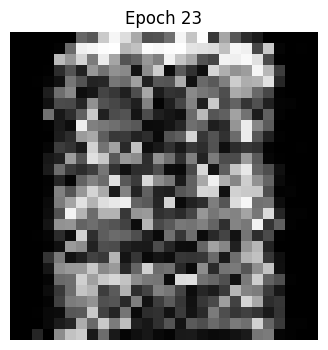

Epoch:24 Iter: 500 errD: -0.11 errG: -0.42
Epoch:24 Iter: 1000 errD: -0.17 errG: -0.39
Epoch:24 Iter: 1500 errD: -0.08 errG: -0.42
Epoch:24 Iter: 2000 errD: -0.12 errG: -0.43
Epoch:24 Iter: 2500 errD: 0.05 errG: -0.44
Epoch:24 Iter: 3000 errD: -0.14 errG: -0.42
Epoch:24 Iter: 3500 errD: -0.03 errG: -0.47


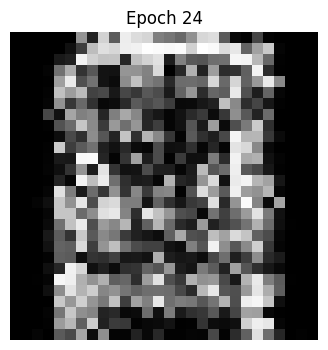

Epoch:25 Iter: 500 errD: -0.14 errG: -0.44
Epoch:25 Iter: 1000 errD: -0.06 errG: -0.48
Epoch:25 Iter: 1500 errD: -0.10 errG: -0.41
Epoch:25 Iter: 2000 errD: -0.07 errG: -0.43
Epoch:25 Iter: 2500 errD: 0.08 errG: -0.47
Epoch:25 Iter: 3000 errD: -0.10 errG: -0.46
Epoch:25 Iter: 3500 errD: -0.15 errG: -0.41


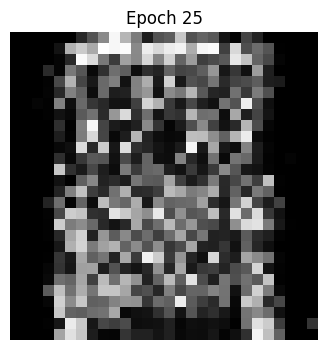

Epoch:26 Iter: 500 errD: -0.11 errG: -0.42
Epoch:26 Iter: 1000 errD: -0.03 errG: -0.49
Epoch:26 Iter: 1500 errD: -0.09 errG: -0.44
Epoch:26 Iter: 2000 errD: -0.05 errG: -0.51
Epoch:26 Iter: 2500 errD: -0.06 errG: -0.47
Epoch:26 Iter: 3000 errD: -0.06 errG: -0.44
Epoch:26 Iter: 3500 errD: -0.07 errG: -0.44


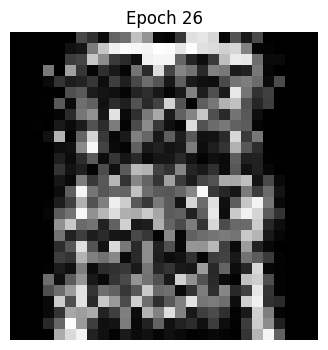

Epoch:27 Iter: 500 errD: -0.08 errG: -0.46
Epoch:27 Iter: 1000 errD: -0.10 errG: -0.43
Epoch:27 Iter: 1500 errD: 0.04 errG: -0.45
Epoch:27 Iter: 2000 errD: -0.12 errG: -0.49
Epoch:27 Iter: 2500 errD: -0.12 errG: -0.46
Epoch:27 Iter: 3000 errD: -0.02 errG: -0.46
Epoch:27 Iter: 3500 errD: -0.05 errG: -0.41


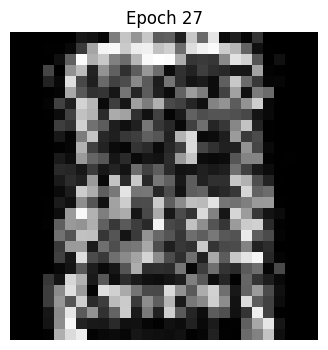

Epoch:28 Iter: 500 errD: -0.14 errG: -0.44
Epoch:28 Iter: 1000 errD: -0.11 errG: -0.49
Epoch:28 Iter: 1500 errD: -0.09 errG: -0.47
Epoch:28 Iter: 2000 errD: -0.08 errG: -0.51
Epoch:28 Iter: 2500 errD: -0.11 errG: -0.46
Epoch:28 Iter: 3000 errD: -0.14 errG: -0.42
Epoch:28 Iter: 3500 errD: -0.06 errG: -0.44


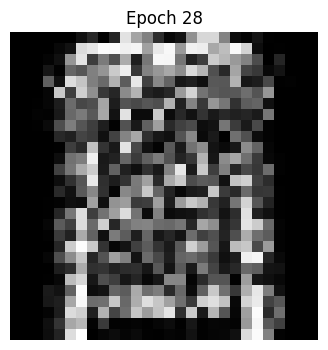

Epoch:29 Iter: 500 errD: -0.07 errG: -0.45
Epoch:29 Iter: 1000 errD: 0.06 errG: -0.44
Epoch:29 Iter: 1500 errD: -0.11 errG: -0.45
Epoch:29 Iter: 2000 errD: -0.12 errG: -0.43
Epoch:29 Iter: 2500 errD: -0.20 errG: -0.38
Epoch:29 Iter: 3000 errD: -0.17 errG: -0.42
Epoch:29 Iter: 3500 errD: -0.15 errG: -0.43


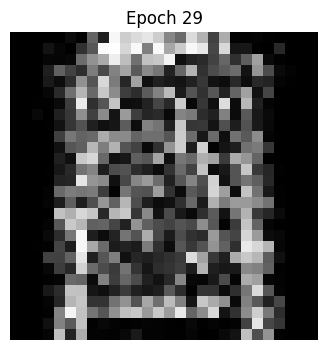

Epoch:30 Iter: 500 errD: -0.04 errG: -0.48
Epoch:30 Iter: 1000 errD: -0.05 errG: -0.49
Epoch:30 Iter: 1500 errD: -0.07 errG: -0.52
Epoch:30 Iter: 2000 errD: -0.11 errG: -0.46
Epoch:30 Iter: 2500 errD: -0.03 errG: -0.48
Epoch:30 Iter: 3000 errD: -0.03 errG: -0.47
Epoch:30 Iter: 3500 errD: -0.12 errG: -0.43


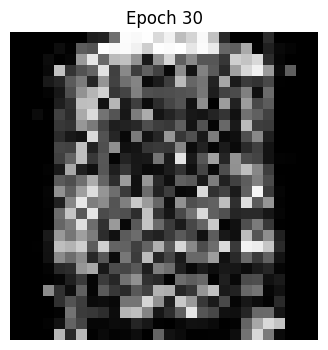

In [30]:
ERRD = np.zeros(config.num_epochs)
ERRG = np.zeros(config.num_epochs)
N = len(dataloader)
device = next(generator.parameters()).device

for epoch in range(config.num_epochs):
    for iteration, (images, labels) in enumerate(dataloader):
        batch_size = images.size(0)
        images = images.view(batch_size, -1).to(device)
        labels = labels.to(device)
        labels_onehot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float().to(device)

        #### Discriminator stage ####
        discriminator.zero_grad()

        real_with_condition = torch.cat([images, labels_onehot], dim=1)
        output_real = discriminator(real_with_condition).squeeze()

        noise = torch.randn(batch_size, config.noise_size, device=device)
        noise_with_condition = torch.cat([noise, labels_onehot], dim=1)
        fake = generator(noise_with_condition)
        fake_detached = fake.detach()
        fake_with_condition = torch.cat([fake_detached, labels_onehot], dim=1)
        output_fake = discriminator(fake_with_condition).squeeze()

        errD_base = -(torch.mean(output_real) - torch.mean(output_fake))

        # Gradient Penalty
        lambda_gp = 10.0
        epsilon = torch.rand(batch_size, 1, device=device)
        epsilon = epsilon.expand_as(images)
        interpolated = epsilon * images + (1 - epsilon) * fake_detached

        interpolated_with_condition = torch.cat([interpolated, labels_onehot], dim=1)
        interpolated_with_condition.requires_grad_(True)
        output_interpolated = discriminator(interpolated_with_condition).squeeze()

        gradients = torch.autograd.grad(
            outputs=output_interpolated,
            inputs=interpolated_with_condition,
            grad_outputs=torch.ones_like(output_interpolated),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )[0]

        grads_image = gradients[:, :images.shape[1]] # Градиенты только по изображению, а не по меткам
        gradients_norm = grads_image.view(batch_size, -1).norm(2, dim=1)
        gradient_penalty = ((gradients_norm - 1) ** 2).mean()
        errD = errD_base + lambda_gp * gradient_penalty

        ERRD[epoch] += errD.item()
        errD.backward()
        optim_D.step()

        #### Generator stage ####
        generator.zero_grad()

        fake_with_condition_for_g = torch.cat([fake, labels_onehot], dim=1)
        output_fake_for_g = discriminator(fake_with_condition_for_g).squeeze()
        errG = -torch.mean(output_fake_for_g)

        ERRG[epoch] += errG.item()
        errG.backward()
        optim_G.step()

        if (iteration+1) % config.print_freq == 0:
            print('Epoch:{} Iter: {} errD: {:.2f} errG: {:.2f}'.format(epoch+1,
                                                                       iteration+1,
                                                                       errD.item(),
                                                                       errG.item()))

    # Генерация тестового изображения
    fixed_noise_with_condition = torch.cat([fixed_noise, fixed_label_onehot], dim=1) # Добавляем инфорамацию о метке для генератора
    test_epoch_generation = generator(fixed_noise_with_condition)
    plt.figure(figsize=(4, 4))
    plt.imshow(test_epoch_generation[0].detach().cpu().numpy().reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    plt.title(f'Epoch {epoch+1}')
    plt.show()

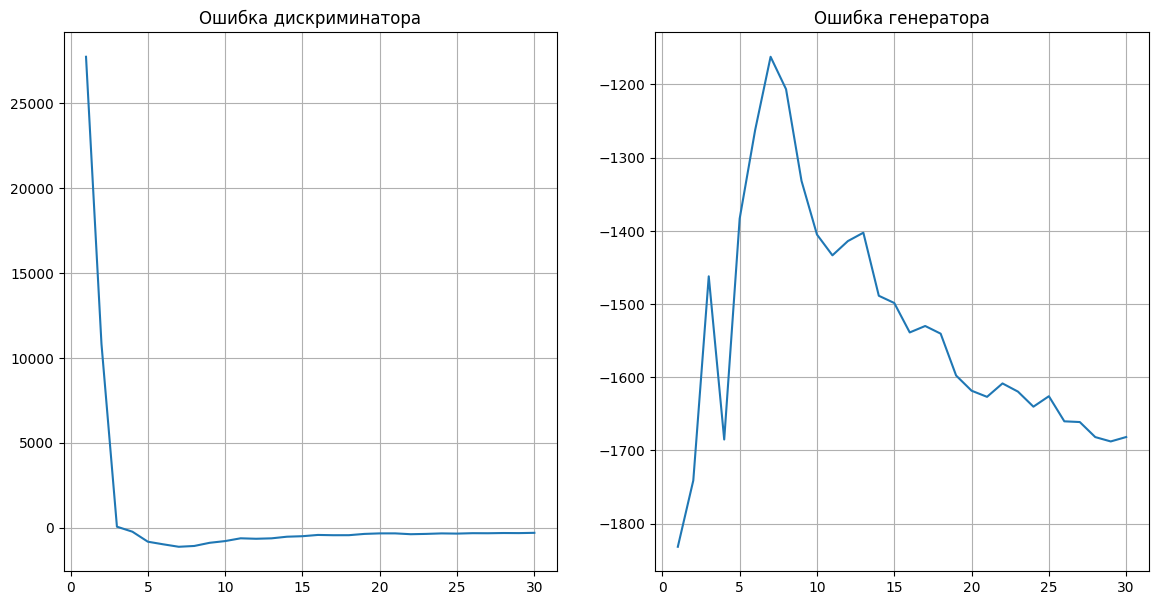

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].plot(np.arange(1, config.num_epochs + 1), ERRD)
axs[0].set_title('Ошибка дискриминатора')
axs[0].grid()

axs[1].plot(np.arange(1, config.num_epochs + 1), ERRG)
axs[1].set_title('Ошибка генератора')
axs[1].grid()

plt.show()

Характер обучения точно такой же, как в случае безусловного WGAN с gradient penalty.

In [42]:
def show_real_samples(label, dataset, num_samples=16):
    indices = [i for i, (_, lbl) in enumerate(dataset) if lbl == label]

    if len(indices) < num_samples:
        print(f"Внимание: в датасете только {len(indices)} изображений с меткой {label}.")
        num_samples = len(indices)

    selected_indices = random.sample(indices, num_samples)

    plt.figure(figsize=(6, 7))
    for i, idx in enumerate(selected_indices):
        image, _ = dataset[idx]
        plt.subplot(4, 4, i + 1)
        plt.imshow(image.squeeze().numpy(), cmap='Greys_r')
        plt.axis('off')
    plt.suptitle(f'Реальные изображения: класс {label}')
    plt.show()

In [43]:
def generate_samples(label):
    label_onehot = torch.nn.functional.one_hot(torch.full((config.batch_size,), label), num_classes=num_classes).float()
    noise.data.normal_(0, 1)
    noise_with_condition = torch.cat([noise, label_onehot], dim=1)
    fake = generator(noise_with_condition)

    plt.figure(figsize=(6, 7))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(fake[i].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
        plt.axis('off')
    plt.suptitle(f'Сгенерированные изображения: класс {label}')
    plt.show()

Продемострируем условную генерацию для различных классов

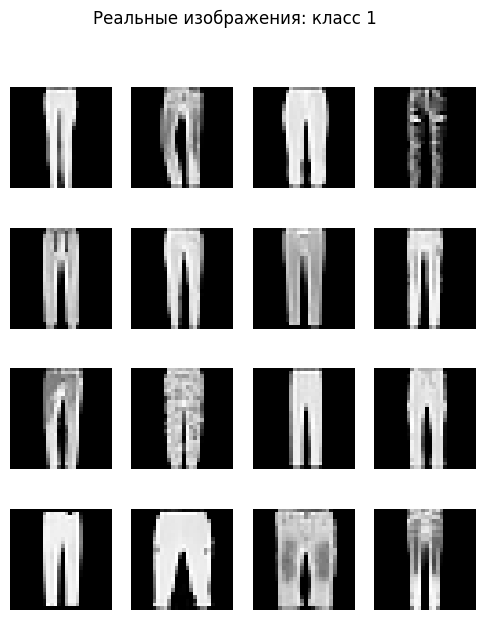

In [46]:
show_real_samples(1, train, 16)

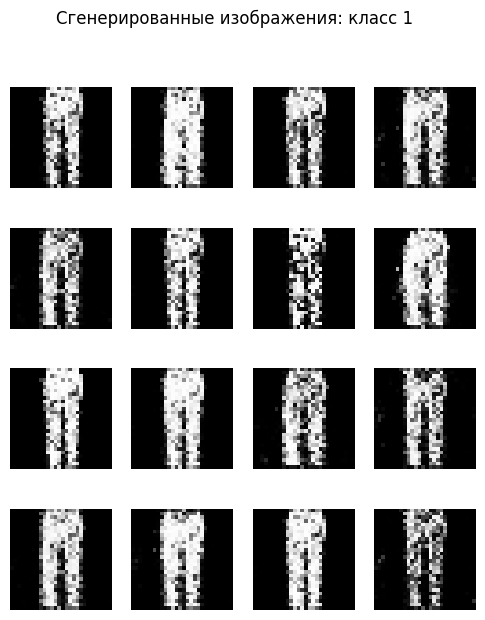

In [47]:
generate_samples(1)

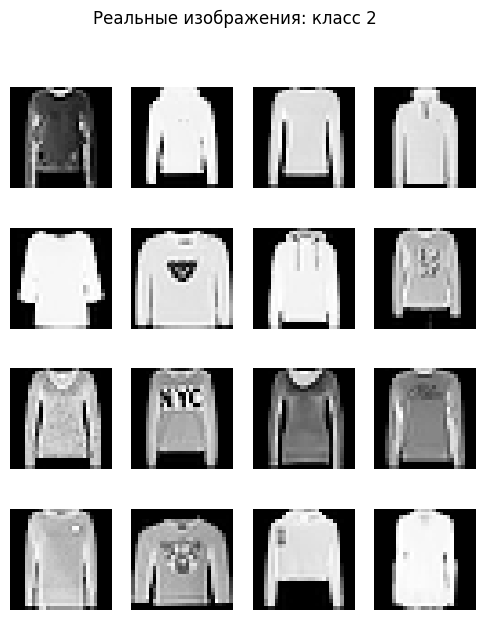

In [48]:
show_real_samples(2, train, 16)

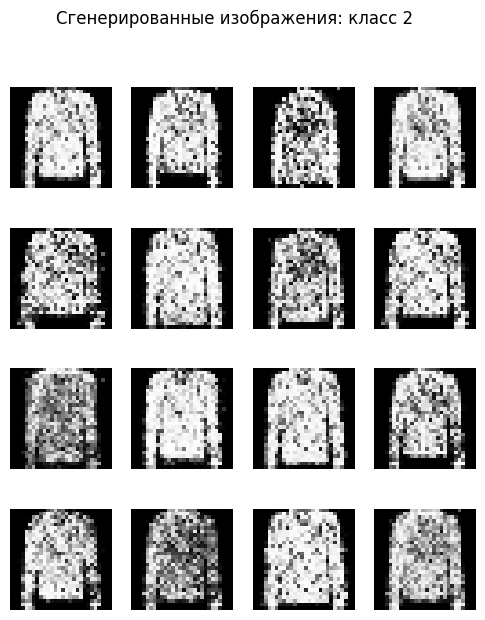

In [49]:
generate_samples(2)

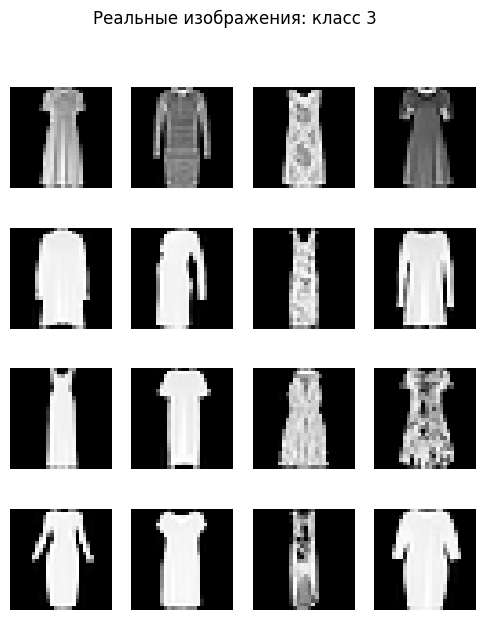

In [50]:
show_real_samples(3, train, 16)

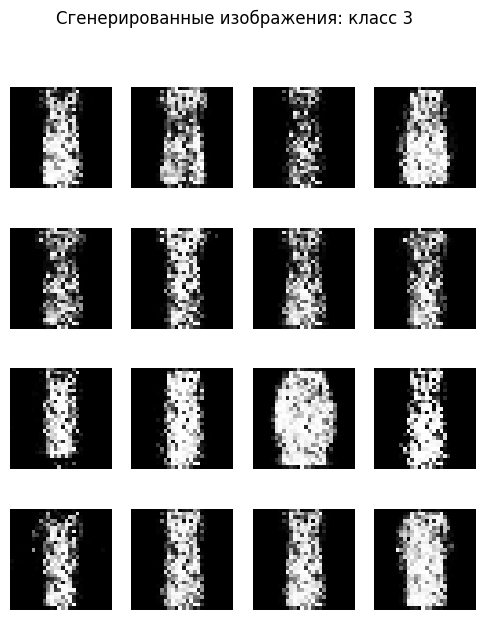

In [52]:
generate_samples(3)

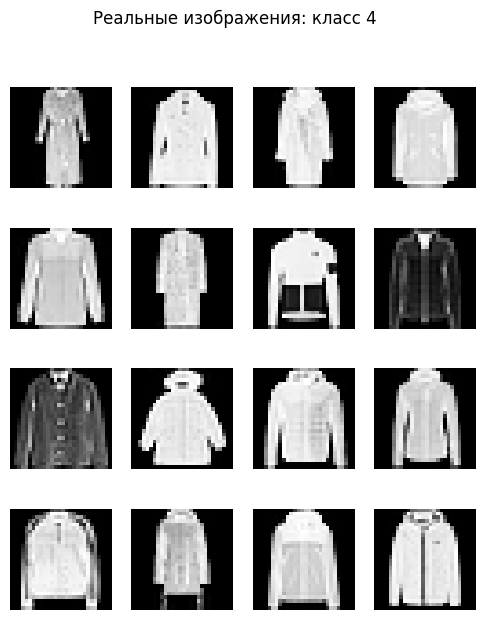

In [44]:
show_real_samples(4, train, 16)

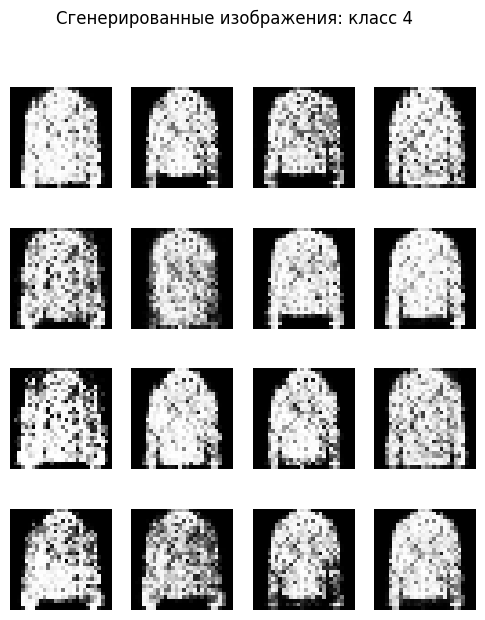

In [45]:
generate_samples(4)

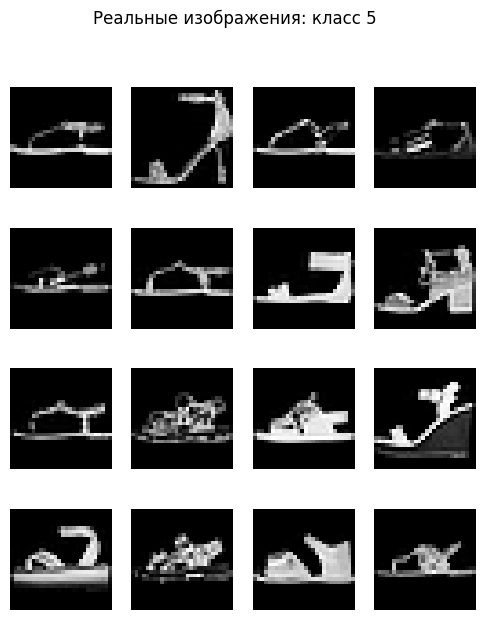

In [53]:
show_real_samples(5, train, 16)

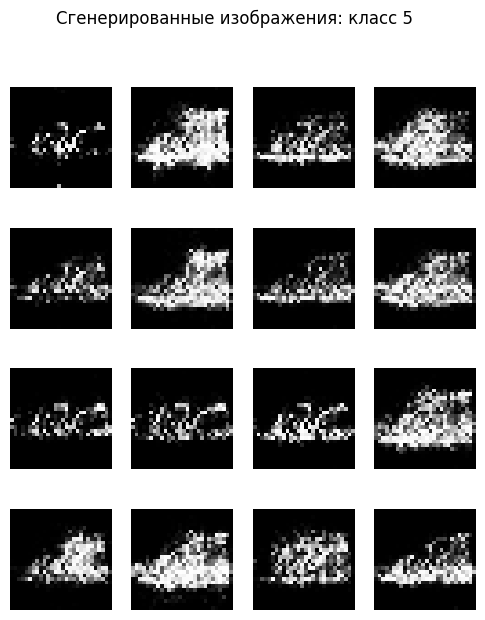

In [54]:
generate_samples(5)

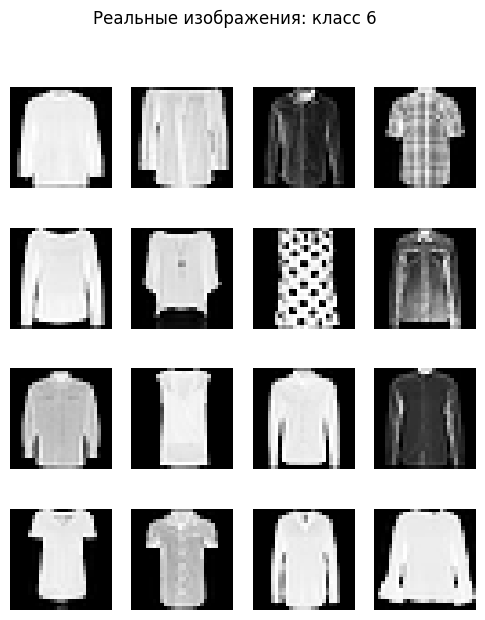

In [55]:
show_real_samples(6, train, 16)

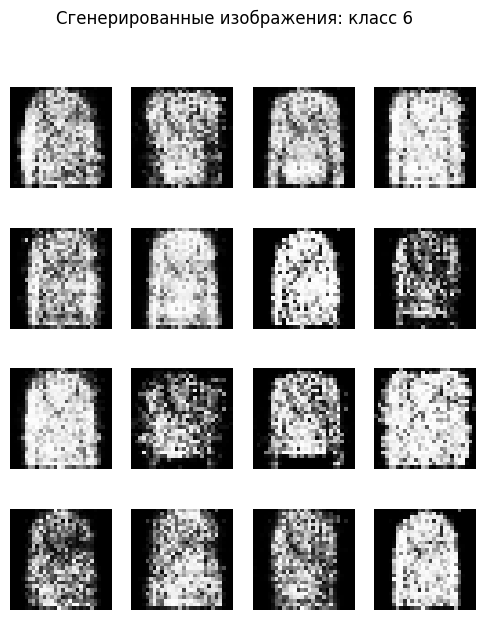

In [56]:
generate_samples(6)

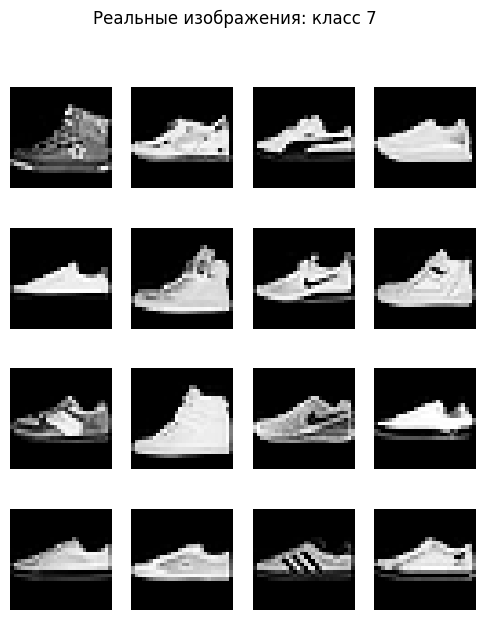

In [57]:
show_real_samples(7, train, 16)

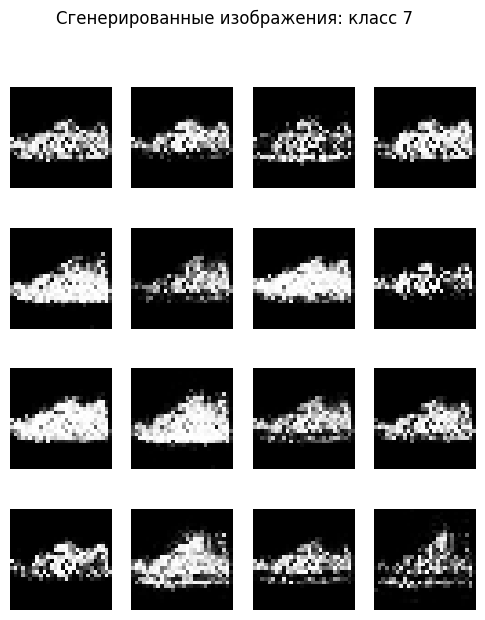

In [58]:
generate_samples(7)

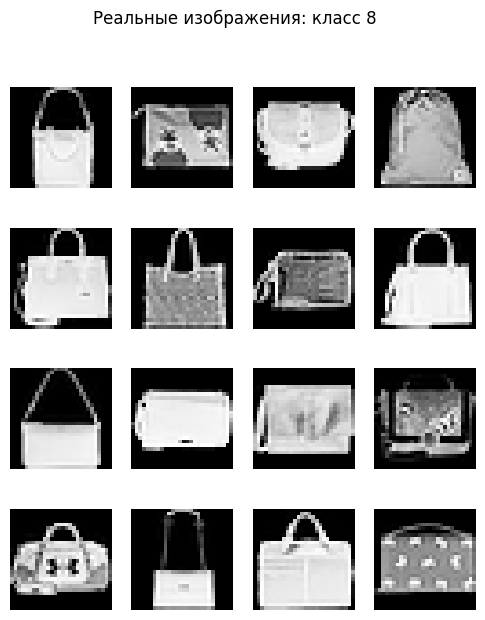

In [59]:
show_real_samples(8, train, 16)

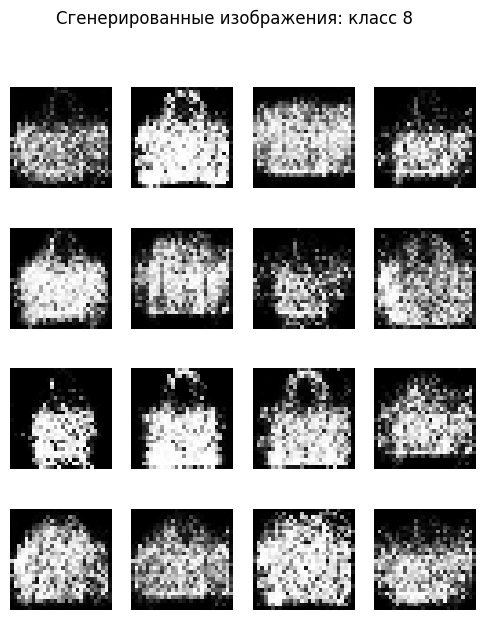

In [60]:
generate_samples(8)

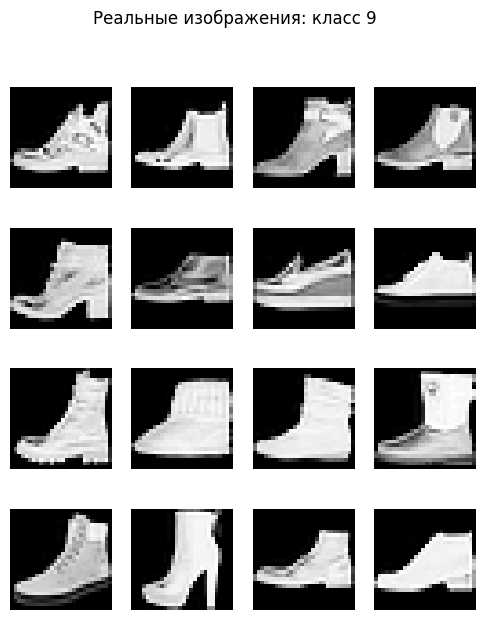

In [61]:
show_real_samples(9, train, 16)

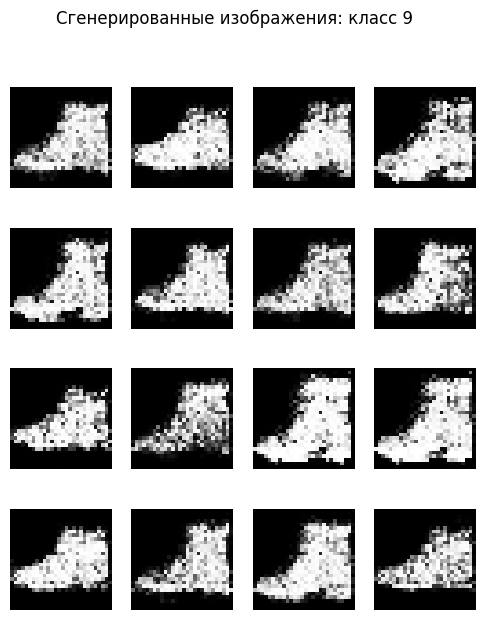

In [62]:
generate_samples(9)

Сгенерированные изображения не отличаются высоким качеством, но при этом условная генерация работает: изображения похожи на реальные объекты соответствующего класса. Также генерация довольно вариативная, не происходит полного mode collapse.

## Вывод

В данной работе были реализованы различные подходы к обучению генеративно-состязательных сетей и продемонстрированы результаты обучения простых моделей генератора и дискриминатора на задаче генерации черно-белых изображений низкого разрешения (набор данных FashionMNIST).

* Vanilla GAN (минимизация JSD по параметрам генератора) показал себя хорошо по качеству итоговой генерации в тестах и стабильности обучения, но стоит учитывать, что количество эпох обучения было небольшим. При более длительном обучении затухание градиентов, свойственное для этого типа GAN, могло не позволить достигнуть пикового качества WGAN. Mode collapse визуально проявляется сильно.

* WGAN + weight clipping (минимизация WD по параметрам генератора с ограничением градиентов через обрезание значений параметров модели) показал худшее качество генерации при фиксированном количестве эпох обучения, чем Vanilla GAN, при этом mode collapse гораздо менее выражен. Процесс обучения сильно не стабилен.

* WGAN + gradient penalty (минимизация WD по параметрам генератора с квадратичным штрафом за превышение нормой градиента критика значения 1) показал сопоставимиое качество с WGAN + weight clipping при фиксированном количестве эпох обучения, при этом процесс обучения разделяется на два различимых этапа: обучение критика 1-Липшицевости, сопровождаемое увеличением ошибки генератора, и минимизация генератором выученного расстояния Вассерштейна, сопровождаемое улучшением качества генерации. Таким образом процесс обучения стал гораздо более стабильным по сравнению в weight clipping.

* cWGAN + gradient penalty (условный WGAN c gradient penalty) имеет те же особенности, что и безусловный WGAN с gradient penalty, но проивзодит управляемую генерацию.